# Evaluación Parcial 1 - Deep Learning (DLY0100)
## Clasificación de Fashion-MNIST con un MLP en Keras

<center><img src="https://github.com/zalandoresearch/fashion-mnist/raw/master/doc/img/fashion-mnist-sprite.png" width="550"></center>

**Integrantes:** Nicolas Osses

**Cómo ejecutar:** abrir en Google Colab, activar GPU (Entorno de ejecución > Cambiar tipo de entorno > T4) y ejecutar todo. Demora aprox. 30 min con GPU. Para una prueba rápida se puede bajar `EPOCAS` en la sección 2.

### Contenido
1. Introducción
2. Librerías y parámetros
3. Lectura de datos
4. Exploración de datos
    - 4.1 Dimensiones y valores faltantes
    - 4.2 Distribución de clases
    - 4.3 Imágenes de ejemplo
    - 4.4 Intensidad de los píxeles
5. Preprocesamiento
6. Funciones de activación, error y salida
7. Modelo y funciones auxiliares
8. Modelo base
9. Experimentos con parámetros de entrenamiento (épocas, learning rate, batch size)
10. Comparación de funciones (activación y pérdida)
11. Optimización y regularización
12. Arquitectura
13. Modelo final
14. Evaluación en test
15. Comparación de todas las configuraciones
16. Interpretación de resultados y posibles mejoras
17. Conclusiones

## 1. Introducción

### Problema
Queremos clasificar imágenes de prendas de Zalando en 10 categorías. Es un problema de **clasificación multiclase**: cada imagen pertenece a una sola clase.

El objetivo es implementar un MLP con Keras, ajustar sus hiperparámetros mediante experimentos controlados y evaluarlo con accuracy, precision, recall y F1.

### Dataset
- 60.000 imágenes de entrenamiento y 10.000 de prueba.
- Cada imagen es de 28x28 píxeles en escala de grises, es decir 784 píxeles.
- Cada píxel es un entero entre 0 y 255 (mayor valor = más oscuro).
- En formato tabla, cada fila es una imagen con 785 columnas: la primera es la etiqueta (`label`) y las otras 784 son los píxeles (`pixel1` ... `pixel784`).

## 2. Librerías y parámetros

In [1]:
# Librerías
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))
plt.rcParams['figure.dpi'] = 100

TensorFlow: 2.20.0 | Keras: 3.13.2
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dejamos todos los parámetros generales en una sola celda, así es fácil encontrarlos y cambiarlos.

In [2]:
# Datos
IMG_ROWS, IMG_COLS = 28, 28
NUM_CLASSES = 10
VAL_SIZE = 10000          # imágenes del train que se separan para validación
SEED = 42                 # semilla fija -> resultados reproducibles

# Ruta de los CSV (si no existen se descarga el dataset con Keras)
PATH = './'
TRAIN_CSV = PATH + 'fashion-mnist_train.csv'
TEST_CSV  = PATH + 'fashion-mnist_test.csv'

# Entrenamiento (valores base; se ajustan en los experimentos)
EPOCAS = 15
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

keras.utils.set_random_seed(SEED)

## 3. Lectura de datos

Hay 10 clases:

- **0**: T-shirt/top
- **1**: Trouser
- **2**: Pullover
- **3**: Dress
- **4**: Coat
- **5**: Sandal
- **6**: Shirt
- **7**: Sneaker
- **8**: Bag
- **9**: Ankle boot

Los datos de train y test vienen por separado. Si los CSV entregados están en `PATH` se leen directamente; si no, se descargan con `keras.datasets.fashion_mnist` y se pasan al mismo formato de tabla (`label` + 784 píxeles). Así el resto del notebook funciona igual en ambos casos.

In [3]:
CLASES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def cargar_datos():
    if os.path.exists(TRAIN_CSV) and os.path.exists(TEST_CSV):
        print('Leyendo CSV desde', PATH)
        return pd.read_csv(TRAIN_CSV), pd.read_csv(TEST_CSV)

    print('No se encontraron los CSV -> se descarga con keras.datasets')
    (X_tr, y_tr), (X_te, y_te) = keras.datasets.fashion_mnist.load_data()
    columnas = ['label'] + [f'pixel{i}' for i in range(1, 785)]
    a_tabla = lambda X, y: pd.DataFrame(np.column_stack([y, X.reshape(len(X), -1)]), columns=columnas)
    return a_tabla(X_tr, y_tr), a_tabla(X_te, y_te)

train_data, test_data = cargar_datos()
train_data.head()

No se encontraron los CSV -> se descarga con keras.datasets
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Exploración de datos

### 4.1 Dimensiones y valores faltantes

In [4]:
print('Fashion-MNIST train -> filas:', train_data.shape[0], '| columnas:', train_data.shape[1])
print('Fashion-MNIST test  -> filas:', test_data.shape[0],  '| columnas:', test_data.shape[1])
print('Valores faltantes   -> train:', train_data.isnull().sum().sum(), '| test:', test_data.isnull().sum().sum())
print('Rango de los píxeles:', train_data.iloc[:, 1:].values.min(), '-', train_data.iloc[:, 1:].values.max())

Fashion-MNIST train -> filas: 60000 | columnas: 785
Fashion-MNIST test  -> filas: 10000 | columnas: 785
Valores faltantes   -> train: 0 | test: 0
Rango de los píxeles: 0 - 255


### 4.2 Distribución de clases

Contamos cuántas imágenes hay de cada clase. Empezamos por el train.

T-shirt/top :  6000  (10.0%)
Trouser     :  6000  (10.0%)
Pullover    :  6000  (10.0%)
Dress       :  6000  (10.0%)
Coat        :  6000  (10.0%)
Sandal      :  6000  (10.0%)
Shirt       :  6000  (10.0%)
Sneaker     :  6000  (10.0%)
Bag         :  6000  (10.0%)
Ankle boot  :  6000  (10.0%)


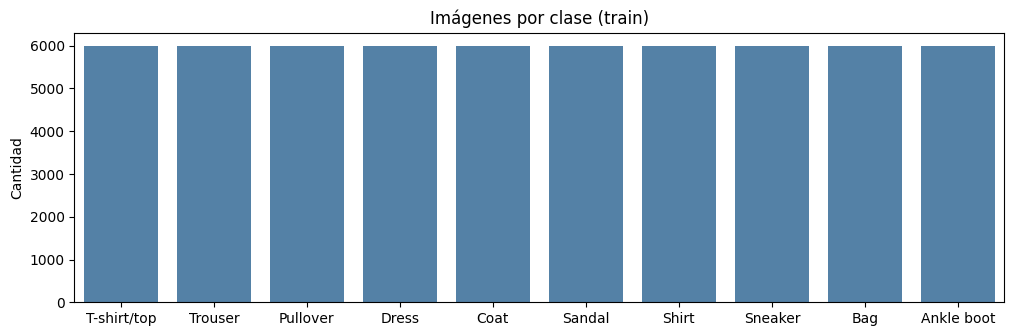

In [5]:
def distribucion_clases(data, titulo, grafico=True):
    conteo = data['label'].value_counts().sort_index()
    for k, n in conteo.items():
        print(f'{CLASES[k]:<12s}: {n:>5d}  ({n / len(data):.1%})')
    if grafico:
        plt.figure(figsize=(12, 3.5))
        ax = sns.countplot(x=data['label'].map(dict(enumerate(CLASES))), order=CLASES, color='steelblue')
        ax.set(title=titulo, xlabel='', ylabel='Cantidad')
        plt.show()

distribucion_clases(train_data, 'Imágenes por clase (train)')

Todas las clases tienen 6.000 imágenes (10% cada una). Revisamos lo mismo en el test.

T-shirt/top :  1000  (10.0%)
Trouser     :  1000  (10.0%)
Pullover    :  1000  (10.0%)
Dress       :  1000  (10.0%)
Coat        :  1000  (10.0%)
Sandal      :  1000  (10.0%)
Shirt       :  1000  (10.0%)
Sneaker     :  1000  (10.0%)
Bag         :  1000  (10.0%)
Ankle boot  :  1000  (10.0%)


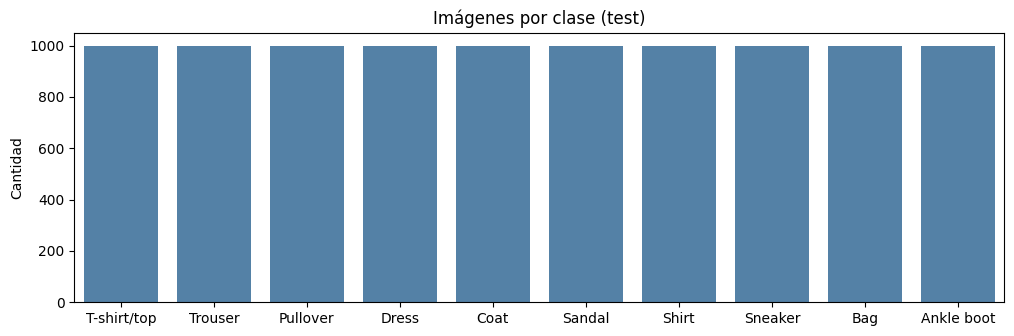

In [6]:
distribucion_clases(test_data, 'Imágenes por clase (test)')

En el test también hay 1.000 imágenes por clase (10% cada una).

### 4.3 Imágenes de ejemplo

Mostramos 4 imágenes de cada clase, con su etiqueta arriba. Cada fila de la tabla se vuelve a armar como matriz de 28x28 para poder dibujarla.

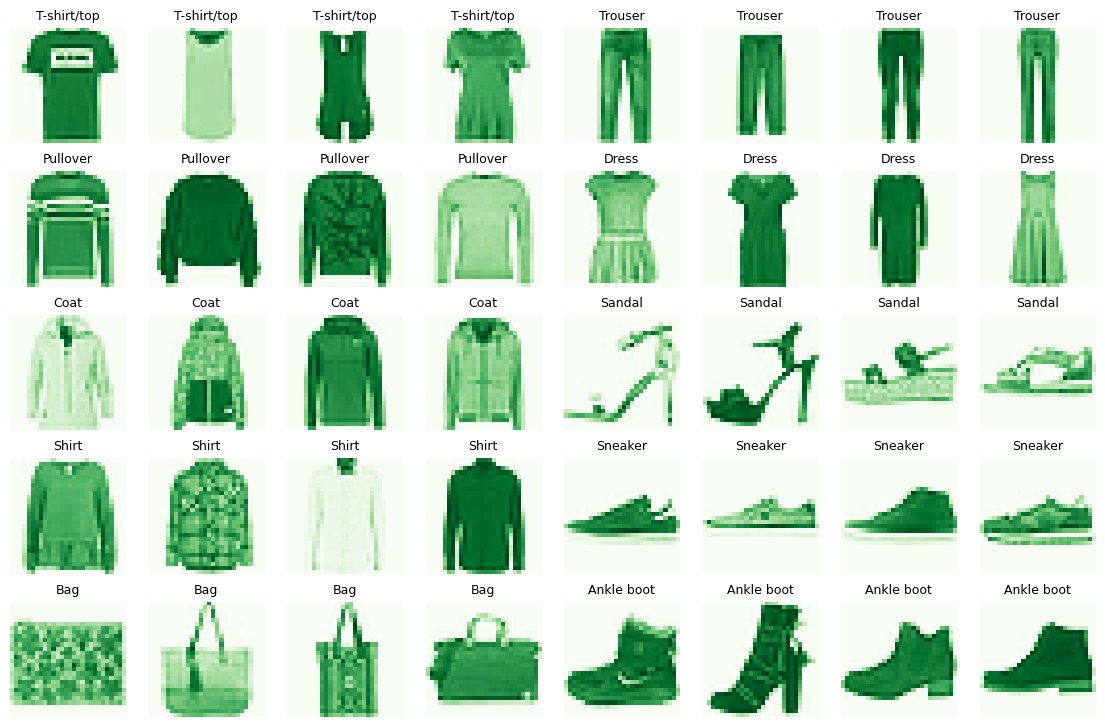

In [7]:
def mostrar_ejemplos(data, cmap='Greens'):
    ejemplos = data.groupby('label').head(4).sort_values('label', kind='stable')   # 4 por clase = 40
    fig, axes = plt.subplots(5, 8, figsize=(14, 9))
    for a, (_, fila) in zip(axes.ravel(), ejemplos.iterrows()):
        a.imshow(fila.values[1:].reshape(IMG_ROWS, IMG_COLS), cmap=cmap)
        a.set_title(CLASES[fila['label']], fontsize=9)
        a.axis('off')
    plt.show()

mostrar_ejemplos(train_data, 'Greens')   # train

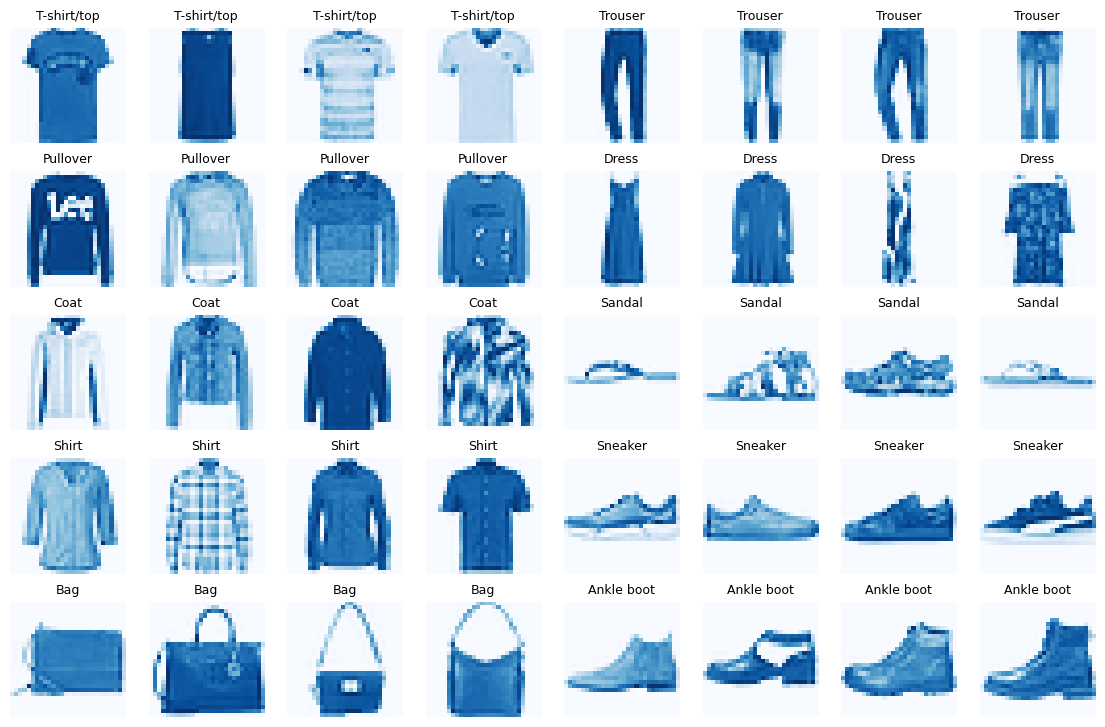

In [8]:
mostrar_ejemplos(test_data, 'Blues')     # test

### 4.4 Intensidad de los píxeles
Vemos cómo se distribuyen los valores de los píxeles para decidir cómo escalarlos.

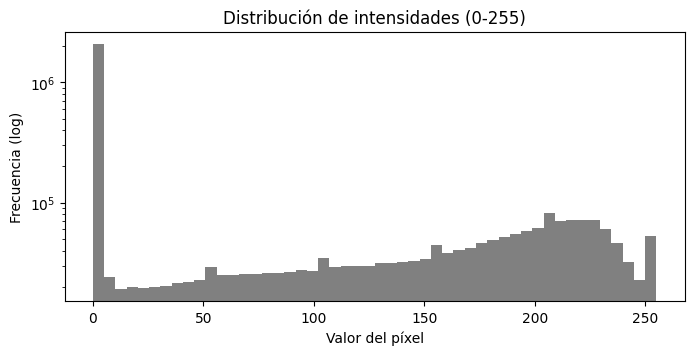

In [9]:
plt.figure(figsize=(8, 3.5))
plt.hist(train_data.iloc[:5000, 1:].values.ravel(), bins=50, color='gray')
plt.yscale('log'); plt.title('Distribución de intensidades (0-255)')
plt.xlabel('Valor del píxel'); plt.ylabel('Frecuencia (log)'); plt.show()

**Observaciones:**
- No hay valores faltantes, así que no hay que imputar nada.
- Las clases están balanceadas en train y test, por lo que el accuracy es una métrica válida.
- Los píxeles van de 0 a 255 y la mayoría es fondo (0), así que hay que escalarlos.
- Algunas clases se ven muy parecidas (Shirt, T-shirt, Pullover, Coat). Probablemente ahí van a estar la mayoría de los errores.

## 5. Preprocesamiento

Pasos y justificación:

1. **Separar validación (10.000 imágenes, estratificado):** lo usamos para ajustar hiperparámetros sin tocar el test. Al estratificar, la validación mantiene el 10% por clase.
2. **Separar etiqueta y píxeles:** la columna `label` es la `y` y las 784 restantes son la `X`. Los datos ya vienen aplanados, que es justo lo que necesita un MLP (las capas `Dense` reciben vectores). A diferencia de una CNN, no hace falta reordenarlos a 28x28x1.
3. **Escalar a [0, 1]:** dividir por 255 evita valores grandes que desestabilizan el entrenamiento.
4. **Estandarizar:** restamos la media y dividimos por la desviación del train. Con entradas centradas en 0 la red converge más rápido. Se usan solo datos de train para no filtrar información de validación/test.
5. **One-hot en las etiquetas:** necesario para usar `CategoricalCrossentropy` con label smoothing y MSE, y así comparar pérdidas con el mismo formato.

No usamos data augmentation porque al aplanar la imagen el MLP no aprovecha tanto la información espacial. Lo dejamos como mejora para una CNN.

In [10]:
# 1) Separar validación estratificada
train_df, val_df = train_test_split(train_data, test_size=VAL_SIZE,
                                    stratify=train_data['label'], random_state=SEED)

# 2) y 3) Separar X / y y escalar a [0, 1]
def preprocesar(data):
    y = data['label'].values
    X = data.iloc[:, 1:].values.astype('float32') / 255.0
    return X, y

X_train_p, y_train = preprocesar(train_df)
X_val_p,   y_val   = preprocesar(val_df)
X_test_p,  y_test  = preprocesar(test_data)

# 4) Estandarizar con la media y desviación del TRAIN
MEDIA, DESV = X_train_p.mean(), X_train_p.std()
X_train_p, X_val_p, X_test_p = [(X - MEDIA) / DESV for X in (X_train_p, X_val_p, X_test_p)]

# 5) Etiquetas one-hot
Y_train, Y_val, Y_test = [keras.utils.to_categorical(y, NUM_CLASSES) for y in (y_train, y_val, y_test)]

Revisamos las dimensiones finales y que el preprocesamiento haya quedado bien.

In [11]:
print('Train -> X:', X_train_p.shape, '| Y:', Y_train.shape)
print('Val   -> X:', X_val_p.shape,   '| Y:', Y_val.shape)
print('Test  -> X:', X_test_p.shape,  '| Y:', Y_test.shape)
print(f'\nMedia/desv usadas: {MEDIA:.4f} / {DESV:.4f}')
print(f'Train después de estandarizar -> media {X_train_p.mean():.3f}, desv {X_train_p.std():.3f}')
print('Ejemplo one-hot de', CLASES[y_train[0]], '->', Y_train[0])

Train -> X: (50000, 784) | Y: (50000, 10)
Val   -> X: (10000, 784) | Y: (10000, 10)
Test  -> X: (10000, 784) | Y: (10000, 10)

Media/desv usadas: 0.2863 / 0.3532
Train después de estandarizar -> media 0.000, desv 1.000
Ejemplo one-hot de Ankle boot -> [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


Comprobamos que la separación estratificada mantuvo el balance de clases.

--- Train ---
T-shirt/top :  5000  (10.0%)
Trouser     :  5000  (10.0%)
Pullover    :  5000  (10.0%)
Dress       :  5000  (10.0%)
Coat        :  5000  (10.0%)
Sandal      :  5000  (10.0%)
Shirt       :  5000  (10.0%)
Sneaker     :  5000  (10.0%)
Bag         :  5000  (10.0%)
Ankle boot  :  5000  (10.0%)

--- Validación ---
T-shirt/top :  1000  (10.0%)
Trouser     :  1000  (10.0%)
Pullover    :  1000  (10.0%)
Dress       :  1000  (10.0%)
Coat        :  1000  (10.0%)
Sandal      :  1000  (10.0%)
Shirt       :  1000  (10.0%)
Sneaker     :  1000  (10.0%)
Bag         :  1000  (10.0%)
Ankle boot  :  1000  (10.0%)


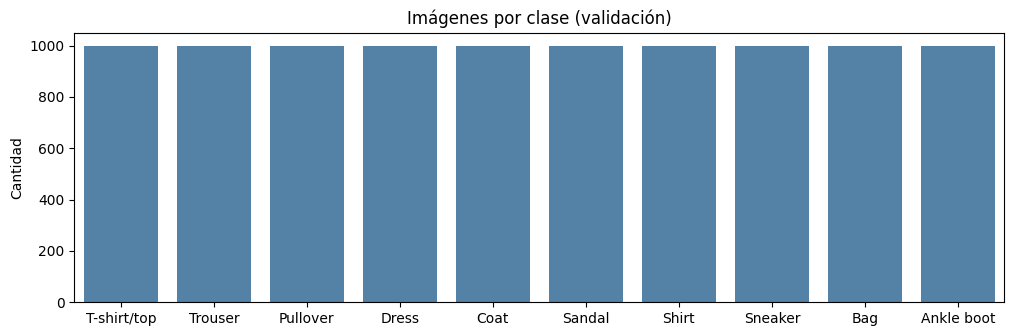

In [12]:
print('--- Train ---'); distribucion_clases(train_df, '', grafico=False)
print('\n--- Validación ---'); distribucion_clases(val_df, 'Imágenes por clase (validación)')

## 6. Funciones de activación, error y salida

Programamos las funciones a mano con operaciones de TensorFlow y comparamos el resultado con las funciones de la librería para verificar que estén bien.

| Función | Fórmula | Uso |
|---|---|---|
| ReLU | $\max(0, x)$ | Capas ocultas |
| Leaky ReLU | $x$ si $x>0$, si no $0.3x$ | Capas ocultas (evita neuronas muertas) |
| Sigmoid | $1/(1+e^{-x})$ | Capas ocultas (para comparar) |
| Tanh | $(e^x-e^{-x})/(e^x+e^{-x})$ | Capas ocultas (para comparar) |
| Softmax | $e^{z_i}/\sum_j e^{z_j}$ | Salida: pasa los 10 valores a probabilidades |
| Entropía cruzada | $-\sum y_k \log(p_k)$ | Pérdida principal |
| MSE | $\frac{1}{K}\sum (p_k - y_k)^2$ | Pérdida alternativa para comparar |

In [13]:
# Funciones de activación (desde cero)
def relu(x):              return tf.maximum(x, 0.0)
def leaky_relu(x, a=0.3): return tf.where(x > 0, x, a * x)
def sigmoid(x):           return 1 / (1 + tf.exp(-x))
def tanh(x):              return (tf.exp(x) - tf.exp(-x)) / (tf.exp(x) + tf.exp(-x))

# Función de salida
def softmax(z):
    z = z - tf.reduce_max(z, axis=1, keepdims=True)   # restar el máximo evita overflow
    e = tf.exp(z)
    return e / tf.reduce_sum(e, axis=1, keepdims=True)

# Funciones de error (reciben probabilidades y etiquetas one-hot)
def cross_entropy(y_onehot, p):
    return tf.reduce_mean(-tf.reduce_sum(y_onehot * tf.math.log(p + 1e-12), axis=1))

def mse(y_onehot, p):
    return tf.reduce_mean((p - y_onehot) ** 2)

# Verificación contra TensorFlow / Keras
x = tf.random.normal([1000]) * 3
logits = tf.random.normal([8, 10])
y_oh = tf.one_hot(tf.random.uniform([8], 0, 10, dtype=tf.int32), 10)
p = tf.nn.softmax(logits)
pruebas = {
    'ReLU':          (relu(x),       tf.nn.relu(x)),
    'Leaky ReLU':    (leaky_relu(x), tf.nn.leaky_relu(x, alpha=0.3)),
    'Sigmoid':       (sigmoid(x),    tf.nn.sigmoid(x)),
    'Tanh':          (tanh(x),       tf.nn.tanh(x)),
    'Softmax':       (softmax(logits), tf.nn.softmax(logits)),
    'Cross-Entropy': (cross_entropy(y_oh, p), keras.losses.CategoricalCrossentropy()(y_oh, p)),
    'MSE':           (mse(y_oh, p),  keras.losses.MeanSquaredError()(y_oh, p)),
}
for nombre, (propia, oficial) in pruebas.items():
    dif = tf.reduce_max(tf.abs(propia - oficial)).numpy()
    print(f'{nombre:14s} diferencia máx. = {dif:.2e}  ')

ReLU           diferencia máx. = 0.00e+00  
Leaky ReLU     diferencia máx. = 0.00e+00  
Sigmoid        diferencia máx. = 0.00e+00  
Tanh           diferencia máx. = 2.38e-07  
Softmax        diferencia máx. = 0.00e+00  
Cross-Entropy  diferencia máx. = 0.00e+00  
MSE            diferencia máx. = 0.00e+00  


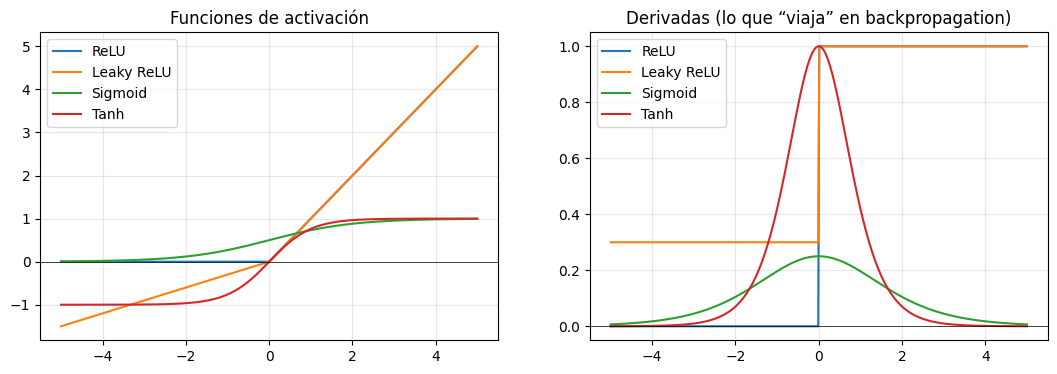

In [14]:
# Gráfico: funciones de activación y sus derivadas
x = tf.linspace(-5.0, 5.0, 400)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for nombre, f in {'ReLU': relu, 'Leaky ReLU': leaky_relu, 'Sigmoid': sigmoid, 'Tanh': tanh}.items():
    with tf.GradientTape() as tape:          # derivada automática
        tape.watch(x)
        y = f(x)
    grad = tape.gradient(y, x)
    ax[0].plot(x, y, label=nombre)
    ax[1].plot(x, grad, label=nombre)
ax[0].set_title('Funciones de activación'); ax[1].set_title('Derivadas (lo que “viaja” en backpropagation)')
for a in ax: a.grid(alpha=.3); a.legend(); a.axhline(0, color='k', lw=.5)
plt.show()

In [15]:
# Ejemplo: de logits a probabilidades y pérdida
logits_ej = tf.constant([[2.0, 0.5, 0.1, 0.0, 1.0, -1, 3.5, -1, 0, -2]])  # salida cruda de la red
p = softmax(logits_ej)
print('Probabilidades:', np.round(p.numpy(), 3), '| suma =', float(tf.reduce_sum(p)))
print('Clase predicha:', CLASES[int(tf.argmax(p, axis=1)[0])])
for real in [6, 0, 9]:   # pérdida si la clase real fuera Shirt, T-shirt o Ankle boot
    y_real = tf.one_hot([real], 10)
    print(f'Si la clase real es {CLASES[real]:12s} -> CE = {float(cross_entropy(y_real, p)):.3f}'
          f' | MSE = {float(mse(y_real, p)):.3f}')

Probabilidades: [[0.151 0.034 0.023 0.02  0.056 0.008 0.678 0.008 0.02  0.003]] | suma = 1.0
Clase predicha: Shirt
Si la clase real es Shirt        -> CE = 0.389 | MSE = 0.013
Si la clase real es T-shirt/top  -> CE = 1.889 | MSE = 0.119
Si la clase real es Ankle boot   -> CE = 5.889 | MSE = 0.148


**Análisis:**
- La derivada de sigmoid no pasa de 0.25 y tanto sigmoid como tanh se aplanan en los extremos. En una red con varias capas esto hace que el gradiente que llega hacia atrás se achique (gradiente desvanecido) y que la red aprenda más lento.
- ReLU tiene derivada 1 para valores positivos, así que no atenúa el gradiente; por eso se espera que converja más rápido. Lo contrastamos en la sección 10.1: ahí sigmoid efectivamente queda última (F1 0.8819) y parte más lento, pero **ReLU, tanh y Leaky ReLU convergen a una velocidad parecida** y terminan separadas por menos de 0.7 puntos (0.8996, 0.8955 y 0.8931). Con solo dos capas ocultas la atenuación alcanza a ser chica, y Adam, que ajusta el paso según el tamaño de cada gradiente, compensa buena parte de la diferencia.
- En el ejemplo, cuando la red se equivoca con mucha seguridad la entropía cruzada crece bastante mientras que el MSE casi no cambia. Por eso la entropía cruzada corrige mejor ese tipo de error. Lo contrastamos en la sección 10.2, donde la diferencia práctica resulta chica: **MSE termina 0.33 puntos de F1 por debajo** de la entropía cruzada (0.8963 contra 0.8996), porque equivocarse con mucha confianza deja de ser frecuente después de las primeras épocas.


## 7. Modelo y funciones auxiliares

Usamos un modelo **Sequential** de Keras: una pila de capas en fila, donde la salida de cada capa es la entrada de la siguiente. Se crea vacío y se le agregan capas con `add`.

Arquitectura base: `784 -> 256 -> 128 -> 10`. Las capas que usamos son:

- **Input(784):** una entrada por píxel.
- **Dense:** capa totalmente conectada (cada neurona se conecta con todas las de la capa anterior). Usamos dos capas ocultas de 256 y 128 neuronas que se van achicando para resumir la información; con este tamaño hay capacidad suficiente sin demasiados parámetros.
- **BatchNormalization** (opcional): normaliza la salida de la capa en cada batch.
- **Activation:** función de activación (ReLU por defecto; se compara en la sección 10).
- **Dropout** (opcional): apaga neuronas al azar durante el entrenamiento.
- **Dense(10, softmax):** capa de salida, una neurona por clase con probabilidades que suman 1.

La función `crear_mlp` recibe estos parámetros (capas, activación, dropout, batch norm, L2) para reutilizarla en todos los experimentos. En cada bloque el orden es `Dense -> BatchNorm -> Activación -> Dropout`.

In [16]:
# Modelo MLP configurable
def crear_mlp(capas=(256, 128), activacion='relu', dropout=0.0, batchnorm=False, l2=0.0):
    reg = regularizers.l2(l2) if l2 else None            # regularización L2 (opcional)
    modelo = keras.Sequential([layers.Input(shape=(784,))])
    for n in capas:                                      # capas ocultas
        modelo.add(layers.Dense(n, kernel_regularizer=reg))
        if batchnorm: modelo.add(layers.BatchNormalization())
        modelo.add(layers.LeakyReLU() if activacion == 'leaky_relu' else layers.Activation(activacion))
        if dropout > 0: modelo.add(layers.Dropout(dropout))
    modelo.add(layers.Dense(10, activation='softmax'))  # capa de salida
    return modelo

crear_mlp().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Configuración base de la que partimos:

| Parámetro | Valor | Motivo |
|---|---|---|
| Optimizador | Adam | Adapta el learning rate por parámetro y suele funcionar bien sin mucho ajuste |
| Learning rate | 0.001 | Valor por defecto de Adam |
| Batch size | 64 | Término medio entre velocidad y generalización |
| Épocas | 15 | Suficiente para comparar configuraciones (se revisa en 9.1) |
| Pérdida | Entropía cruzada | La estándar para clasificación multiclase |

Para los experimentos armamos funciones que entrenan una configuración, calculan las métricas en validación y generan tablas y gráficos. Todas usan la misma semilla para que las comparaciones sean justas.

In [17]:
# Configuración base
BASE = dict(capas=(256, 128), activacion='relu', dropout=0.0, batchnorm=False, l2=0.0,
            perdida='cross_entropy', optimizador='adam', lr=LEARNING_RATE, momentum=0.0,
            batch_size=BATCH_SIZE, epocas=EPOCAS, paciencia=None, scheduler=False)
EPOCAS_EXP = EPOCAS      # épocas por experimento
MEJOR_CFG = dict(BASE)   # se irá actualizando con los mejores resultados

# Funciones de pérdida disponibles
PERDIDAS = {
    'cross_entropy':   lambda: keras.losses.CategoricalCrossentropy(),
    'label_smoothing': lambda: keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    'mse':             lambda: keras.losses.MeanSquaredError(),
}

# Callback: registra el lr y la norma del gradiente de la 1ª capa en cada época
X_muestra, Y_muestra = X_train_p[:2048], Y_train[:2048]
class Monitor(keras.callbacks.Callback):
    def __init__(self, perdida):
        super().__init__(); self.perdida = perdida; self.lr, self.grad = [], []
    def on_epoch_end(self, epoch, logs=None):
        self.lr.append(float(np.array(self.model.optimizer.learning_rate)))
        with tf.GradientTape() as tape:
            loss = self.perdida(Y_muestra, self.model(X_muestra, training=False))
        g = tape.gradient(loss, self.model.trainable_weights[0])   # kernel de la 1ª capa
        self.grad.append(float(tf.norm(g)))

In [18]:
# Función principal de entrenamiento
def entrenar(config=None, verbose=0):
    cfg = {**BASE, **(config or {})}
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)                    # misma inicialización en todos los experimentos
    modelo = crear_mlp(cfg['capas'], cfg['activacion'], cfg['dropout'], cfg['batchnorm'], cfg['l2'])

    # Optimizador
    if cfg['optimizador'] == 'adam':
        opt = keras.optimizers.Adam(learning_rate=cfg['lr'])
    else:
        opt = keras.optimizers.SGD(learning_rate=cfg['lr'], momentum=cfg['momentum'])

    perdida = PERDIDAS[cfg['perdida']]()
    modelo.compile(optimizer=opt, loss=perdida, metrics=['accuracy'])

    # Callbacks
    monitor = Monitor(perdida)
    callbacks = [monitor]
    if cfg['paciencia']:   # detiene si val_loss no mejora y recupera los mejores pesos
        callbacks.append(keras.callbacks.EarlyStopping(monitor='val_loss', patience=cfg['paciencia'],
                                                       restore_best_weights=True, verbose=1))
    if cfg['scheduler']:   # baja el lr a la mitad si val_loss se estanca 2 épocas
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2))

    # Entrenamiento
    t0 = time.time()
    h = modelo.fit(X_train_p, Y_train, validation_data=(X_val_p, Y_val),
                   epochs=cfg['epocas'], batch_size=cfg['batch_size'],
                   callbacks=callbacks, verbose=verbose)

    hist = {'train_loss': h.history['loss'], 'train_acc': h.history['accuracy'],
            'val_loss': h.history['val_loss'], 'val_acc': h.history['val_accuracy'],
            'grad_norm': monitor.grad, 'lr': monitor.lr, 'tiempo': time.time() - t0}
    return modelo, hist

In [19]:
# Predicción y métricas
def probabilidades(modelo, X):
    return modelo.predict(X, batch_size=4096, verbose=0)

def predecir(modelo, X):
    return probabilidades(modelo, X).argmax(1)

def metricas(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return {'Accuracy': accuracy_score(y_true, y_pred), 'Precision': p, 'Recall': r, 'F1': f1}

# Fila resumen de un experimento (métricas sobre VALIDACIÓN)
def resumen(nombre, modelo, h):
    m = metricas(y_val, predecir(modelo, X_val_p))
    vl = np.array(h['val_loss'], dtype=float)
    ok = not np.all(np.isnan(vl))
    return {'Config': nombre, 'Acc_train': h['train_acc'][-1], 'Acc_val': m['Accuracy'],
            'Precision_val': m['Precision'], 'Recall_val': m['Recall'], 'F1_val': m['F1'],
            'Loss_val_min': np.nanmin(vl) if ok else np.nan,
            'Mejor_época': int(np.nanargmin(vl)) + 1 if ok else np.nan,
            'Gap_acc': h['train_acc'][-1] - h['val_acc'][-1],        # train - val: indica overfitting
            'Inestabilidad': np.std(vl[-5:]),                          # variación de val_loss al final
            'Tiempo_s': h['tiempo']}

# Ejecuta un grupo de configuraciones (variando UN parámetro)
TODAS_LAS_TABLAS = []
def experimento(nombre_exp, configs, epocas=None):
    historias, filas, modelos = {}, [], {}
    for etiqueta, cambios in configs.items():
        print(f'Entrenando: {etiqueta}')
        cfg = {**MEJOR_CFG, 'epocas': epocas or EPOCAS_EXP, **cambios}
        modelo, h = entrenar(cfg)
        historias[etiqueta], modelos[etiqueta] = h, modelo
        filas.append(resumen(etiqueta, modelo, h))
    tabla = pd.DataFrame(filas).set_index('Config')
    TODAS_LAS_TABLAS.append(tabla.assign(Experimento=nombre_exp))
    display(tabla.round(4))
    return historias, tabla, modelos

# Actualiza la mejor configuración con el ganador (mayor F1 en validación)
def actualizar_mejor(tabla, configs, claves=None):
    ganador = tabla['F1_val'].idxmax()
    cambios = configs[ganador] if claves is None else {k: configs[ganador][k] for k in claves}
    MEJOR_CFG.update(cambios)
    print(f'Ganador: {ganador} -> se actualiza {cambios}')

In [20]:
# Gráficos comparativos
def graficar(historias, titulo, log=False):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for i, (k, h) in enumerate(historias.items()):
        ep = range(1, len(h['val_loss']) + 1)
        ax[0].plot(ep, h['train_loss'], '--', color=f'C{i}', alpha=.5)
        ax[0].plot(ep, h['val_loss'], color=f'C{i}', label=k)
        ax[1].plot(ep, h['val_acc'], color=f'C{i}', label=k)
    ax[0].set(title='Pérdida  (línea = validación, punteada = train)', xlabel='Época', ylabel='Loss')
    ax[1].set(title='Accuracy en validación', xlabel='Época', ylabel='Accuracy')
    if log: ax[0].set_yscale('log')
    for a in ax: a.grid(alpha=.3); a.legend(fontsize=8)
    fig.suptitle(titulo, fontweight='bold'); plt.tight_layout(); plt.show()

def barras_metricas(tabla, titulo):
    cols = ['Acc_val', 'Precision_val', 'Recall_val', 'F1_val']
    ax = tabla[cols].plot.bar(figsize=(10, 4), rot=0)
    ax.set_ylim(max(0, tabla[cols].min().min() - 0.05), 1)
    ax.set_title(titulo); ax.grid(axis='y', alpha=.3); ax.legend(loc='lower right', fontsize=8)
    plt.show()

## 8. Modelo base
Entrenamos la configuración base para tener un punto de comparación.

Epoch 1/15
782/782 - 7s - 9ms/step - accuracy: 0.8302 - loss: 0.4638 - val_accuracy: 0.8623 - val_loss: 0.3830
Epoch 2/15


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


782/782 - 2s - 3ms/step - accuracy: 0.8709 - loss: 0.3501 - val_accuracy: 0.8766 - val_loss: 0.3438
Epoch 3/15
782/782 - 2s - 3ms/step - accuracy: 0.8849 - loss: 0.3098 - val_accuracy: 0.8762 - val_loss: 0.3377
Epoch 4/15
782/782 - 2s - 3ms/step - accuracy: 0.8945 - loss: 0.2816 - val_accuracy: 0.8793 - val_loss: 0.3375
Epoch 5/15
782/782 - 3s - 4ms/step - accuracy: 0.9021 - loss: 0.2621 - val_accuracy: 0.8791 - val_loss: 0.3370
Epoch 6/15
782/782 - 2s - 3ms/step - accuracy: 0.9069 - loss: 0.2450 - val_accuracy: 0.8777 - val_loss: 0.3523
Epoch 7/15
782/782 - 2s - 3ms/step - accuracy: 0.9122 - loss: 0.2296 - val_accuracy: 0.8785 - val_loss: 0.3550
Epoch 8/15
782/782 - 2s - 3ms/step - accuracy: 0.9181 - loss: 0.2130 - val_accuracy: 0.8861 - val_loss: 0.3445
Epoch 9/15
782/782 - 3s - 3ms/step - accuracy: 0.9226 - loss: 0.2031 - val_accuracy: 0.8911 - val_loss: 0.3322
Epoch 10/15
782/782 - 3s - 4ms/step - accuracy: 0.9273 - loss: 0.1923 - val_accuracy: 0.8890 - val_loss: 0.3400
Epoch 11/15

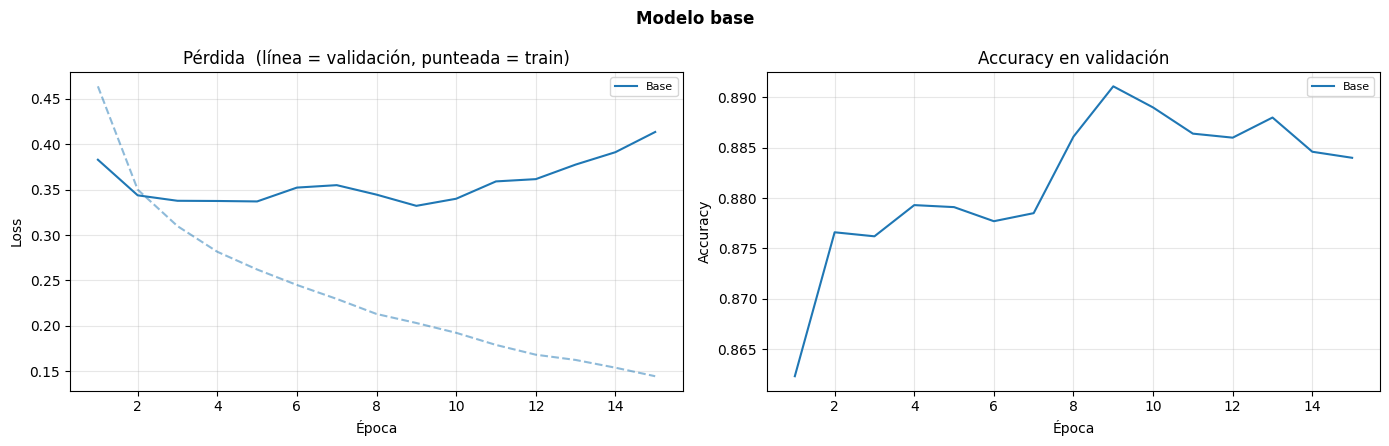

,Acc_train,Acc_val,Precision_val,Recall_val,F1_val,Loss_val_min,Mejor_época,Gap_acc,Inestabilidad,Tiempo_s
Config,,,,,,,,,,
Base,0.9445,0.884,0.8864,0.884,0.8846,0.3322,9,0.0605,0.0202,41.8593


In [21]:
# Entrenamiento del modelo base
modelo_base, hist_base = entrenar(BASE, verbose=2)
graficar({'Base': hist_base}, 'Modelo base')
fila_base = resumen('Base', modelo_base, hist_base)
TODAS_LAS_TABLAS.append(pd.DataFrame([fila_base]).set_index('Config').assign(Experimento='Base'))
display(pd.DataFrame([fila_base]).set_index('Config').round(4))

In [22]:
# ¿En qué clases falla el modelo base? (validación)
print(classification_report(y_val, predecir(modelo_base, X_val_p), target_names=CLASES, digits=3))

              precision    recall  f1-score   support

 T-shirt/top      0.857     0.815     0.835      1000
     Trouser      0.988     0.977     0.982      1000
    Pullover      0.762     0.793     0.777      1000
       Dress      0.910     0.876     0.893      1000
        Coat      0.843     0.778     0.809      1000
      Sandal      0.974     0.954     0.964      1000
       Shirt      0.681     0.749     0.713      1000
     Sneaker      0.924     0.972     0.947      1000
         Bag      0.946     0.982     0.964      1000
  Ankle boot      0.978     0.944     0.961      1000

    accuracy                          0.884     10000
   macro avg      0.886     0.884     0.885     10000
weighted avg      0.886     0.884     0.885     10000



**Análisis del modelo base:**
- Accuracy de validación 0.8840 y F1 macro 0.8846, con accuracy de train 0.9445: la brecha train-validación es de 0.0605.
- La pérdida de validación **no se estanca, sube**: toca su mínimo en la época 9 (0.3322) y de ahí en adelante crece sin parar hasta 0.4136 en la época 15, mientras la de train sigue bajando (0.2031 -> 0.1445). Es sobreajuste, y empieza justo en la época 9.
- El accuracy de validación, en cambio, casi no cambia en ese tramo: 0.8911 en la época 9 y 0.8840 en la 15, o sea baja 0.71 puntos mientras la pérdida sube casi un 25%. El deterioro está sobre todo en la confianza con que se equivoca, que es lo que castiga la entropía cruzada.
- La clase con peor resultado es Shirt (F1 0.713), seguida de Pullover (0.777) y Coat (0.809); todas las demás pasan de 0.80.

Con esto como referencia, probamos cambiar el learning rate, batch size, funciones, regularización y arquitectura.


## 9. Experimentos con parámetros de entrenamiento

En cada experimento cambiamos un solo parámetro y dejamos el resto igual. La opción con mejor F1 en validación se guarda en `MEJOR_CFG` y se usa en los experimentos siguientes.

### 9.1 Épocas

/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


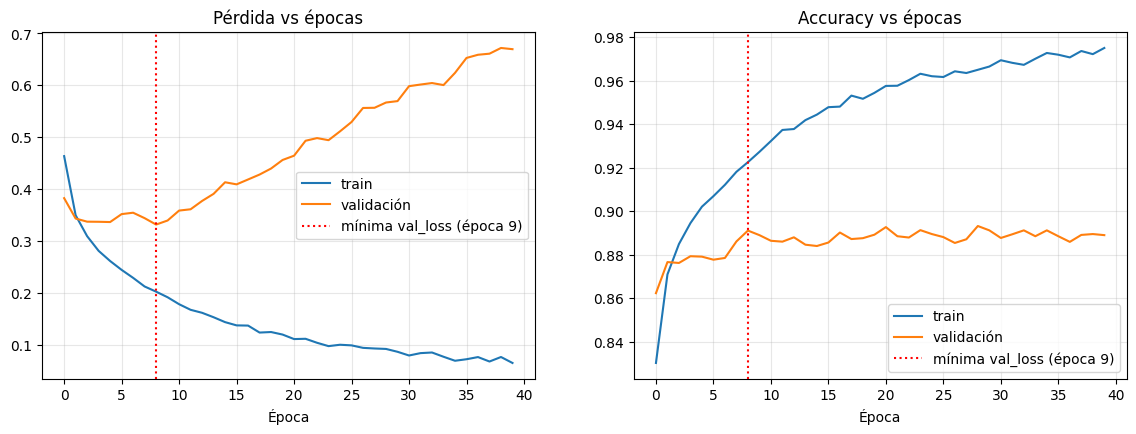

,Acc_train,Acc_val,Loss_train,Loss_val,Gap_acc
Épocas,,,,,
5,0.9021,0.8791,0.2621,0.3370,0.0230
10,0.9273,0.8890,0.1923,0.3400,0.0383
15,0.9445,0.8840,0.1445,0.4136,0.0605
20,0.9545,0.8892,0.1206,0.4564,0.0653
30,0.9666,0.8912,0.0874,0.5697,0.0754
40,0.9751,0.8890,0.0659,0.6696,0.0861


In [23]:
# Experimento: épocas (un entrenamiento largo, observando cada punto)
_, hist_ep = entrenar({**MEJOR_CFG, 'epocas': 40})
mejor_ep = int(np.argmin(hist_ep['val_loss'])) + 1

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(hist_ep['train_loss'], label='train'); ax[0].plot(hist_ep['val_loss'], label='validación')
ax[1].plot(hist_ep['train_acc'], label='train');  ax[1].plot(hist_ep['val_acc'], label='validación')
for a, t in zip(ax, ['Pérdida', 'Accuracy']):
    a.axvline(mejor_ep - 1, color='red', ls=':', label=f'mínima val_loss (época {mejor_ep})')
    a.set(title=f'{t} vs épocas', xlabel='Época'); a.legend(); a.grid(alpha=.3)
plt.show()

tabla_ep = pd.DataFrame([{'Épocas': e, 'Acc_train': hist_ep['train_acc'][e-1], 'Acc_val': hist_ep['val_acc'][e-1],
                          'Loss_train': hist_ep['train_loss'][e-1], 'Loss_val': hist_ep['val_loss'][e-1],
                          'Gap_acc': hist_ep['train_acc'][e-1] - hist_ep['val_acc'][e-1]}
                         for e in [5, 10, 15, 20, 30, 40]]).set_index('Épocas')
display(tabla_ep.round(4))

**Análisis:**
- **Esperábamos** que la validación mejorara hasta cierto punto y después empeorara por sobreajuste.
- **Resultado:** la val_loss más baja está en la época 9 (0.3322). Después sube siempre: 0.4136 en la época 15, 0.5697 en la 30 y 0.6696 en la 40, es decir, se duplica respecto del mínimo. La de train baja al mismo tiempo de 0.2031 a 0.0659 y la brecha de accuracy crece de 0.0383 (época 10) a 0.0861 (época 40).
- El accuracy de validación, en cambio, casi no cambia: 0.8911 en la época 9, 0.8840 en la 15, 0.8912 en la 30 y 0.8890 en la 40, todo dentro de menos de un punto. Las dos métricas no cuentan lo mismo: mientras la pérdida se duplica, la proporción de aciertos se mueve apenas; lo que crece es la confianza con que se equivoca, y eso solo lo ve la pérdida.
- **Contraste con lo esperado:** a medias. El sobreajuste aparece y es evidente en la pérdida, pero apenas se refleja en el accuracy, así que elegir el número de épocas mirando el accuracy daría una respuesta distinta que mirando la pérdida.
- **Decisión:** mantenemos 15 épocas como presupuesto fijo para todos los experimentos, así se comparan con el mismo costo, y dejamos el early stopping (que sigue la val_loss) para el modelo final. 15 es más que las 9 del óptimo de pérdida, pero entre esas dos épocas el accuracy de validación casi no cambia (0.8911 contra 0.8840). Este supuesto se revisa en la sección 16, porque más adelante bajamos el learning rate.


### 9.2 Learning rate

Entrenando: lr=0.0001


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: lr=0.001


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: lr=0.01


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: lr=0.1


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


,Acc_train,Acc_val,Precision_val,Recall_val,F1_val,Loss_val_min,Mejor_época,Gap_acc,Inestabilidad,Tiempo_s
Config,,,,,,,,,,
lr=0.0001,0.9274,0.8996,0.9002,0.8996,0.8996,0.2829,15,0.0278,0.0020,39.3775
lr=0.001,0.9445,0.8840,0.8864,0.8840,0.8846,0.3322,9,0.0605,0.0202,40.7690
lr=0.01,0.8824,0.8628,0.8676,0.8628,0.8631,0.3933,3,0.0196,0.0202,40.2562
lr=0.1,0.1009,0.1000,0.0100,0.1000,0.0182,2.3090,1,0.0009,0.0000,41.9121


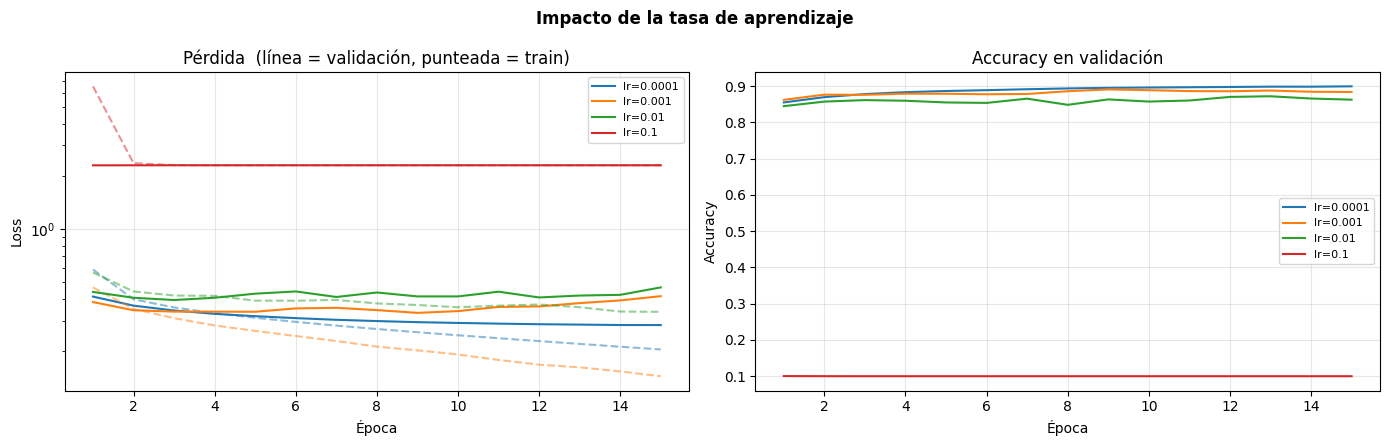

Ganador: lr=0.0001 -> se actualiza {'lr': 0.0001}


In [24]:
# Experimento: learning rate
configs_lr = {f'lr={v}': {'lr': v} for v in [1e-4, 1e-3, 1e-2, 1e-1]}
hist_lr, tabla_lr, _ = experimento('Learning rate', configs_lr)
graficar(hist_lr, 'Impacto de la tasa de aprendizaje', log=True)
actualizar_mejor(tabla_lr, configs_lr)

**Análisis:**
- **Esperábamos** que 0.001 (el valor por defecto de Adam) fuera el mejor equilibrio y que los valores altos hicieran oscilar la pérdida.
- **Resultado:** ganó **0.0001**, con F1 de validación 0.8996 frente a 0.8846 de 0.001: 1.5 puntos de diferencia. Es un margen grande comparado con las diferencias que en este cuaderno tratamos como empate (0.15 a 0.7 puntos, como ReLU contra tanh o label smoothing contra entropía cruzada), así que cuesta más atribuirlo al azar de una sola semilla. Le sigue 0.001, después 0.01 (0.8631) y al final 0.1 (0.0182).
- 0.001 no es el mejor porque sobreajusta antes: su mejor val_loss está en la época 9 y termina con brecha 0.0605. Con 0.0001 la val_loss todavía está bajando en la época 15 (0.2829, la más baja del grupo) y la brecha es menos de la mitad (0.0278).
- Con 0.01 el modelo avanza y retrocede: su mejor época es la 3 y termina con el peor accuracy de train entre los que sí aprendieron (0.8824, contra 0.9274 de 0.0001), es decir, ni siquiera ajusta bien el conjunto de entrenamiento.
- **0.1 no oscila: colapsa.** Accuracy de validación 0.1000 (una de diez clases), val_loss 2.309, que es prácticamente ln(10) = 2.303, el valor de predecir al azar, y F1 macro 0.0182, lo que solo pasa si el modelo entrega siempre la misma clase. La columna Inestabilidad no sirve para justificar esto: para lr=0.1 vale 0.0000 justamente porque la pérdida quedó pegada en el valor del azar, y para 0.01 vale exactamente lo mismo que para 0.001 (0.0202).
- **Comparado con lo que esperábamos:** no se cumplió. El valor por defecto no fue el mejor, y el learning rate alto no produjo una curva ruidosa sino una red muerta que dejó de aprender en la primera época.
- **Decisión:** adoptamos lr = 0.0001 para los experimentos siguientes. Queda pendiente que su mejor época es la 15, o sea la última, señal de que con este learning rate 15 épocas pueden quedar cortas; lo retomamos en la sección 16.


### 9.3 Batch size

Entrenando: batch=16


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: batch=64


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: batch=256


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: batch=1024


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


,Acc_train,Acc_val,Precision_val,Recall_val,F1_val,Loss_val_min,Mejor_época,Gap_acc,Inestabilidad,Tiempo_s
Config,,,,,,,,,,
batch=16,0.9477,0.8927,0.8941,0.8927,0.8928,0.3055,7,0.0550,0.0058,140.7896
batch=64,0.9274,0.8996,0.9002,0.8996,0.8996,0.2829,15,0.0278,0.0020,39.7772
batch=256,0.9065,0.8899,0.8907,0.8899,0.8900,0.3028,15,0.0166,0.0045,15.5926
batch=1024,0.8811,0.8784,0.8790,0.8784,0.8785,0.3470,15,0.0027,0.0072,10.0133


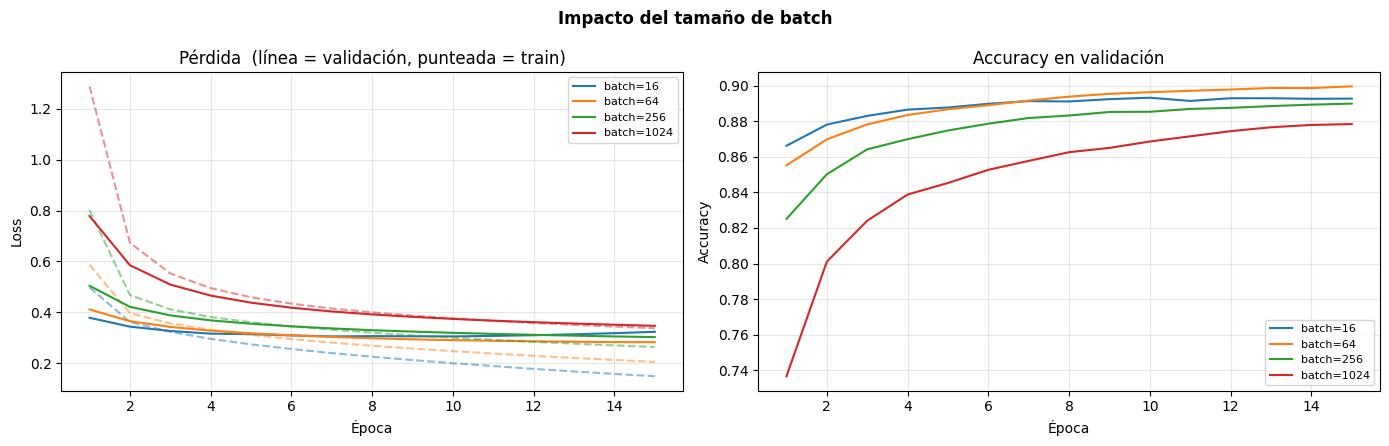

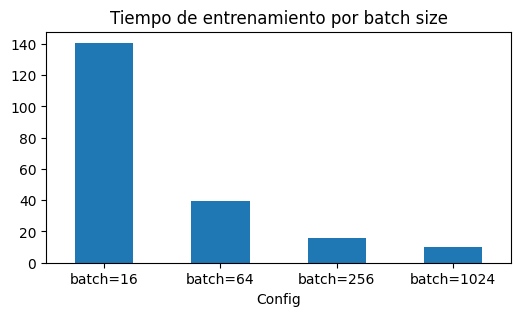

Ganador: batch=64 -> se actualiza {'batch_size': 64}


In [25]:
# Experimento: batch size
configs_bs = {f'batch={v}': {'batch_size': v} for v in [16, 64, 256, 1024]}
hist_bs, tabla_bs, _ = experimento('Batch size', configs_bs)
graficar(hist_bs, 'Impacto del tamaño de batch')
tabla_bs['Tiempo_s'].plot.bar(figsize=(6, 3), title='Tiempo de entrenamiento por batch size', rot=0); plt.show()
actualizar_mejor(tabla_bs, configs_bs)

**Análisis:**
- **Esperábamos** que con batch chico cada época tardara más y el entrenamiento fuera más irregular, y que con batch grande cada época fuera rápida pero hicieran falta más épocas para llegar al mismo resultado.
- **Resultado (F1 de validación y tiempo):** batch 64 **0.8996** en ≈40 s > batch 16 0.8928 en ≈141 s > batch 256 0.8900 en ≈16 s > batch 1024 0.8785 en ≈10 s.
- Batch 16 es el peor negocio del experimento: 3.5 veces más lento que batch 64 para un F1 más bajo. Además es el único cuya mejor época no es la última (la 7), con brecha 0.0550: tantas actualizaciones por época lo hacen sobreajustar dentro del presupuesto de 15 épocas.
- Batch 256 pierde menos de un punto (0.8900) y corre en ≈16 s, 2.5 veces más rápido que batch 64. Si el tiempo fuera una restricción, sería la opción sensata.
- Batch 1024 queda **subentrenado**: F1 0.8785 y una brecha de apenas 0.0027, con accuracy de train 0.8811, el más bajo del grupo. Con 50.000 imágenes de entrenamiento son unas 49 actualizaciones por época, contra 782 con batch 64; sumado al lr 0.0001 elegido en 9.2, los pesos se mueven muy poco en 15 épocas. No es que generalice mal: es que no alcanzó a aprender.
- **Contraste con lo esperado:** se cumplió a medias. El batch chico fue más lento, como se esperaba, pero no ganó en resultado; y el batch grande no solo necesitaba más épocas, con este learning rate quedó bastante atrás.
- **Decisión:** batch 64, que tiene el mejor F1 con un tiempo razonable.
- Ojo con la lectura: 64, 256 y 1024 tienen su mejor val_loss en la época 15, o sea en la última. Con un presupuesto más largo el orden entre ellos podría cambiar, sobre todo para batch 1024; volvemos sobre esto en la sección 16.


## 10. Comparación de funciones

### 10.1 Funciones de activación
Además de las métricas, graficamos la norma del gradiente de la primera capa para ver si hay gradiente desvanecido.

Entrenando: relu


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: leaky_relu


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: tanh


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: sigmoid


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


,Acc_train,Acc_val,Precision_val,Recall_val,F1_val,Loss_val_min,Mejor_época,Gap_acc,Inestabilidad,Tiempo_s
Config,,,,,,,,,,
relu,0.9274,0.8996,0.9002,0.8996,0.8996,0.2829,15,0.0278,0.0020,41.0653
leaky_relu,0.9109,0.8933,0.8933,0.8933,0.8931,0.2988,15,0.0176,0.0025,40.7499
tanh,0.9249,0.8955,0.8959,0.8955,0.8955,0.2841,15,0.0294,0.0028,40.0051
sigmoid,0.8862,0.8822,0.8820,0.8822,0.8819,0.3271,15,0.0040,0.0063,39.8277


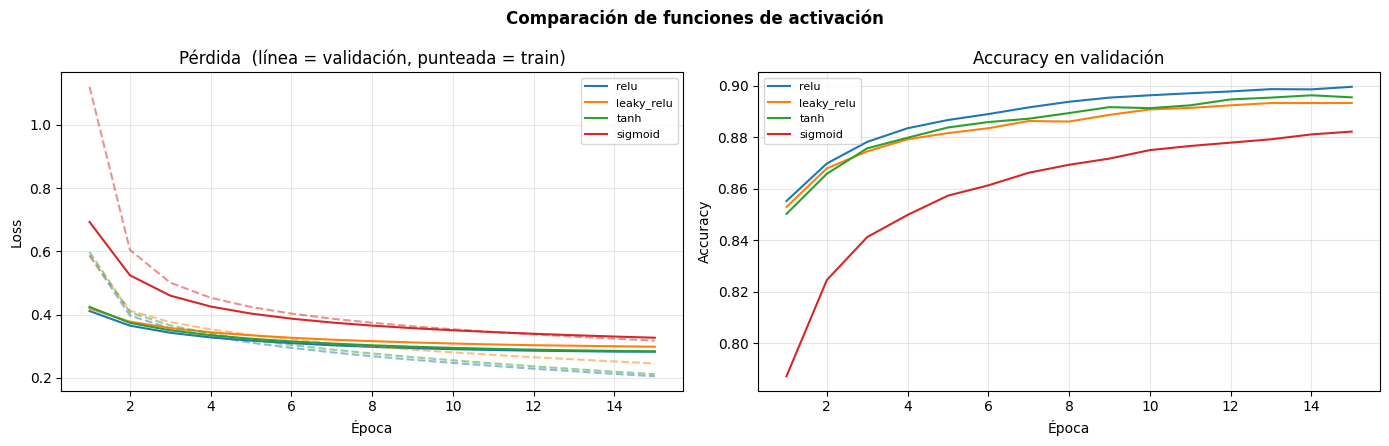

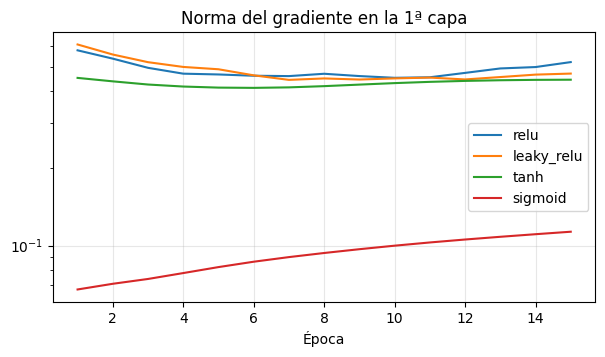

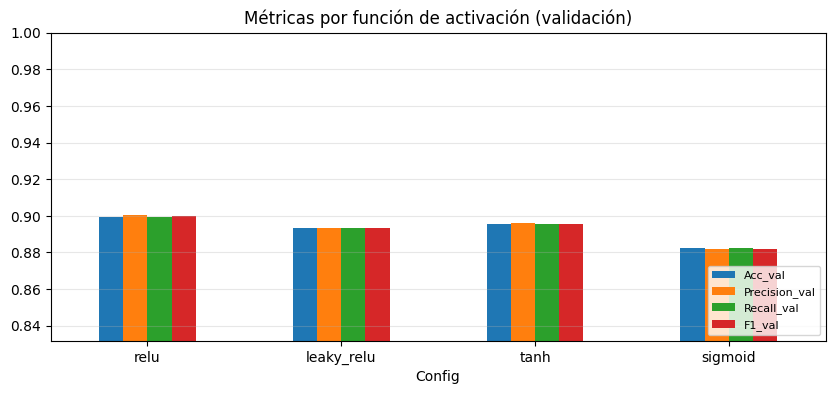

Ganador: relu -> se actualiza {'activacion': 'relu'}


In [26]:
# Experimento: función de activación
configs_act = {a: {'activacion': a} for a in ['relu', 'leaky_relu', 'tanh', 'sigmoid']}
hist_act, tabla_act, _ = experimento('Activación', configs_act)
graficar(hist_act, 'Comparación de funciones de activación')

plt.figure(figsize=(7, 3.5))
for k, h in hist_act.items(): plt.plot(range(1, len(h['grad_norm']) + 1), h['grad_norm'], label=k)
plt.yscale('log'); plt.title('Norma del gradiente en la 1ª capa'); plt.xlabel('Época'); plt.legend(); plt.grid(alpha=.3)
plt.show()
barras_metricas(tabla_act, 'Métricas por función de activación (validación)')
actualizar_mejor(tabla_act, configs_act)

### 10.2 Funciones de pérdida

Entrenando: cross_entropy


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: label_smoothing


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: mse


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


,Acc_train,Acc_val,Precision_val,Recall_val,F1_val,Loss_val_min,Mejor_época,Gap_acc,Inestabilidad,Tiempo_s
Config,,,,,,,,,,
cross_entropy,0.9274,0.8996,0.9002,0.8996,0.8996,0.2829,15,0.0278,0.0020,40.3846
label_smoothing,0.9306,0.9013,0.9014,0.9013,0.9011,0.7372,15,0.0293,0.0022,42.1341
mse,0.9315,0.8966,0.8968,0.8966,0.8963,0.0149,15,0.0349,0.0001,39.3374


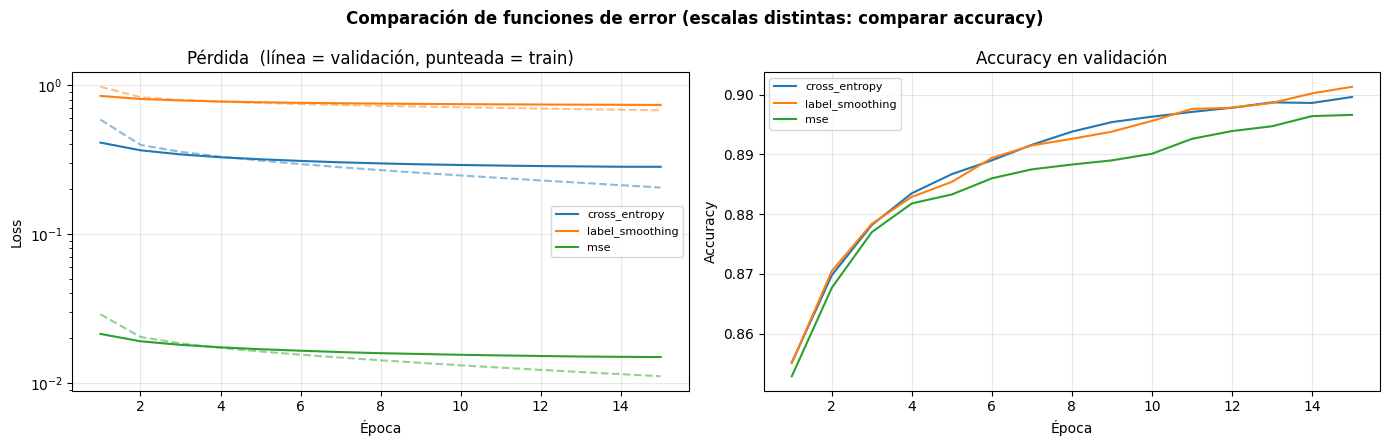

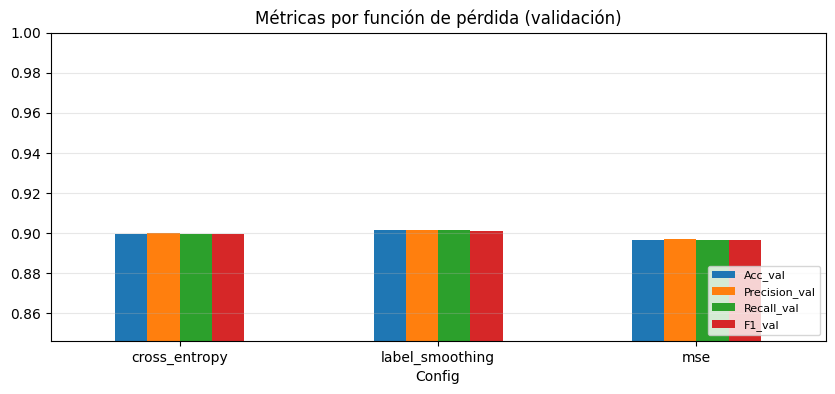

Ganador: label_smoothing -> se actualiza {'perdida': 'label_smoothing'}


In [27]:
# Experimento: función de pérdida
configs_loss = {p: {'perdida': p} for p in ['cross_entropy', 'label_smoothing', 'mse']}
hist_loss, tabla_loss, _ = experimento('Pérdida', configs_loss)
graficar(hist_loss, 'Comparación de funciones de error (escalas distintas: comparar accuracy)', log=True)
barras_metricas(tabla_loss, 'Métricas por función de pérdida (validación)')
actualizar_mejor(tabla_loss, configs_loss)

In [28]:
# Tabla comparativa de funciones (métricas clave)
cols = ['Acc_val', 'Precision_val', 'Recall_val', 'F1_val', 'Loss_val_min', 'Mejor_época', 'Tiempo_s']
tabla_funciones = pd.concat([tabla_act[cols].assign(Tipo='Activación'), tabla_loss[cols].assign(Tipo='Pérdida')])
display(tabla_funciones.round(4))

,Acc_val,Precision_val,Recall_val,F1_val,Loss_val_min,Mejor_época,Tiempo_s,Tipo
Config,,,,,,,,
relu,0.8996,0.9002,0.8996,0.8996,0.2829,15,41.0653,Activación
leaky_relu,0.8933,0.8933,0.8933,0.8931,0.2988,15,40.7499,Activación
tanh,0.8955,0.8959,0.8955,0.8955,0.2841,15,40.0051,Activación
sigmoid,0.8822,0.8820,0.8822,0.8819,0.3271,15,39.8277,Activación
cross_entropy,0.8996,0.9002,0.8996,0.8996,0.2829,15,40.3846,Pérdida
label_smoothing,0.9013,0.9014,0.9013,0.9011,0.7372,15,42.1341,Pérdida
mse,0.8966,0.8968,0.8966,0.8963,0.0149,15,39.3374,Pérdida


**Análisis de las funciones de activación (10.1):**
- **Esperábamos**, por lo visto en la sección 6, que ReLU y Leaky ReLU convergieran más rápido que tanh, y las tres bastante más rápido que sigmoid.
- **Resultado (F1 de validación):** relu 0.8996 > tanh 0.8955 > leaky_relu 0.8931 > sigmoid 0.8819. Entre las tres primeras hay menos de 0.7 puntos y en las curvas avanzan a una velocidad muy parecida época a época; con una sola semilla esa diferencia es demasiado chica para declarar una ganadora clara.
- La que sí se separa es **sigmoid**: en la primera época va en ≈0.79 de accuracy de validación cuando las otras tres ya están en ≈0.85, y la norma del gradiente de la primera capa se mantiene varias veces por debajo de las demás durante todo el entrenamiento, tal como anticipaba la derivada máxima de 0.25.
- Lo que le pasa a sigmoid es **subajuste, no sobreajuste**: termina con el accuracy de train más bajo del grupo (0.8862, contra 0.9274 de ReLU) y una brecha de apenas 0.0040. No es que generalice mal, es que en 15 épocas no alcanza a aprender lo que las otras.
- **Contraste con la hipótesis:** se cumplió en parte. Sigmoid quedó última y es claramente la más lenta, como se esperaba, pero entre ReLU, Leaky ReLU y tanh no hubo diferencia apreciable de velocidad ni de resultado.
- **Decisión:** seguimos con ReLU, que tiene el mejor F1 (0.8996), dejando dicho que tanh habría servido casi igual.

**Análisis de las funciones de pérdida (10.2):**
- **Esperábamos** que la entropía cruzada fuera la mejor por ser la pérdida propia de clasificación, y que MSE aprendiera más lento porque junto con softmax sus gradientes son pequeños.
- **Resultado:** ganó **label smoothing** con F1 0.9011 frente a 0.8996 de la entropía cruzada, o sea 0.15 puntos. Es un empate técnico: las curvas de accuracy de las dos son casi idénticas en todas las épocas y una diferencia así cabe dentro del ruido de una sola semilla.
- **MSE** queda en 0.8963, menos de medio punto por debajo de la entropía cruzada. Su curva de accuracy va por debajo de las otras dos, pero siempre por ese mismo margen chico. El freno teórico de MSE junto con softmax no tiene que ver con la profundidad de la red: aparece cuando el modelo se equivoca con mucha confianza, porque ahí el softmax está saturado y el gradiente de MSE se achica justo cuando haría falta una corrección grande. Pasadas las primeras épocas ese caso es poco frecuente, así que el efecto acumulado en 15 épocas queda en 0.33 puntos de F1.
- Los valores de `Loss_val_min` (0.2829, 0.7372 y 0.0149) no son comparables entre sí porque miden cosas distintas: con label smoothing la etiqueta objetivo ya no vale 1, así que la pérdida nunca puede acercarse a 0, y MSE está en otra escala. Por eso comparamos accuracy y F1.
- En la salida usamos softmax porque cada imagen pertenece a una sola clase y necesitamos probabilidades que sumen 1.
- **Comparado con lo esperado:** no se cumplió del todo: la entropía cruzada no fue la mejor por margen medible y MSE no quedó tan atrás como se esperaba.
- **Decisión:** adoptamos label smoothing por tener el mejor F1, asumiendo que la ventaja es mínima y que la entropía cruzada simple habría sido igual de defendible.


## 11. Optimización y regularización

### 11.1 Optimizadores
Cada optimizador se prueba con su learning rate típico, ya que SGD necesita uno más alto que Adam para que la comparación tenga sentido.

Entrenando: SGD (lr=0.01)


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: SGD + momentum (lr=0.01)


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: Adam (lr=0.0001)


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


,Acc_train,Acc_val,Precision_val,Recall_val,F1_val,Loss_val_min,Mejor_época,Gap_acc,Inestabilidad,Tiempo_s
Config,,,,,,,,,,
SGD (lr=0.01),0.9004,0.8848,0.8847,0.8848,0.8838,0.7686,15,0.0156,0.0039,40.2369
SGD + momentum (lr=0.01),0.9571,0.8966,0.8978,0.8966,0.8965,0.7510,9,0.0605,0.0018,41.2287
Adam (lr=0.0001),0.9306,0.9013,0.9014,0.9013,0.9011,0.7372,15,0.0293,0.0022,40.2941


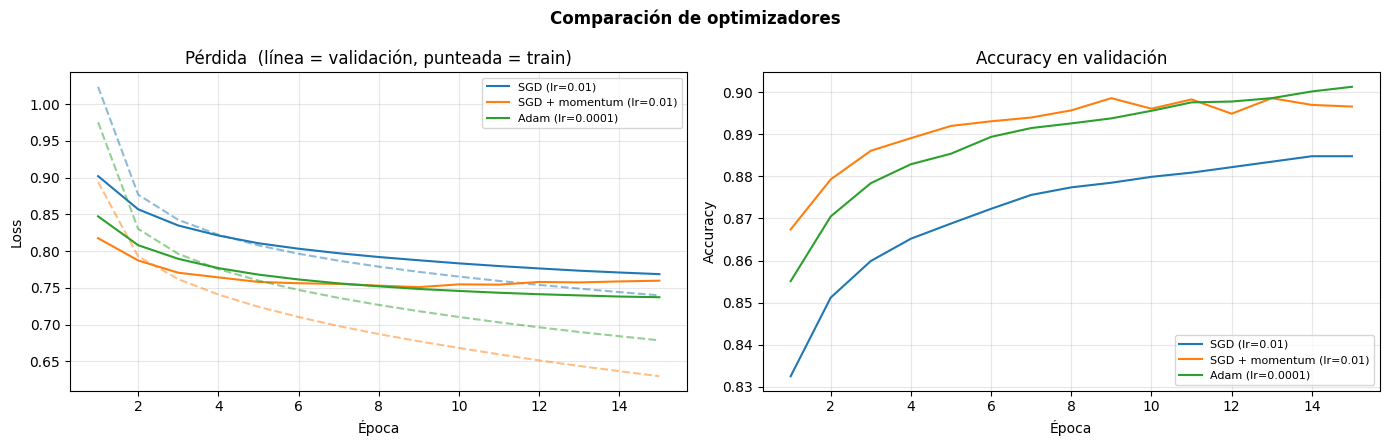

Ganador: Adam (lr=0.0001) -> se actualiza {'optimizador': 'adam', 'lr': 0.0001, 'momentum': 0.0}


In [29]:
# Experimento: optimizador
configs_opt = {
    'SGD (lr=0.01)':            {'optimizador': 'sgd',  'lr': 1e-2, 'momentum': 0.0},
    'SGD + momentum (lr=0.01)': {'optimizador': 'sgd',  'lr': 1e-2, 'momentum': 0.9},
    f"Adam (lr={MEJOR_CFG['lr']})": {'optimizador': 'adam', 'lr': MEJOR_CFG['lr'], 'momentum': 0.0},
}
hist_opt, tabla_opt, _ = experimento('Optimizador', configs_opt)
graficar(hist_opt, 'Comparación de optimizadores')
actualizar_mejor(tabla_opt, configs_opt)

**Análisis:**
- **Esperábamos** que SGD sin momentum fuera el más lento, que el momentum lo acelerara y que Adam convergiera más rápido desde el principio.
- **Resultado (F1 de validación):** Adam (lr 0.0001) 0.9011 > SGD + momentum 0.8965 > SGD 0.8838.
- SGD sin momentum efectivamente avanza lento: su mejor val_loss está en la época 15 y termina con brecha 0.0156, o sea le faltó entrenamiento, no le sobró.
- **SGD + momentum fue el más rápido al inicio** —sube antes que los otros dos en las curvas—, pero también es el que más sobreajusta: su mejor val_loss está en la época 9 y de ahí empeora, y termina con accuracy de train 0.9571 y brecha 0.0605, la mayor del experimento.
- **Adam ganó al final, y no por ser más rápido, sino por sobreajustar menos:** su mejor val_loss está en la última época (15) y su brecha es 0.0293, menos de la mitad que la de SGD + momentum.
- **Contraste con lo esperado:** no se cumplió del todo. El papel de "más rápido al principio" lo tuvo SGD + momentum, y la ventaja de Adam aparece recién al final. Hay que tener presente además que Adam corre con lr 0.0001 (elegido en 9.2) y SGD con 0.01, así que se comparan optimizadores cada uno con su learning rate, no a igualdad de paso.
- **Decisión:** seguimos con Adam y lr 0.0001.

### 11.2 Regularización
Para que el overfitting se note más usamos una red más grande (512-256) y 30 épocas. Probamos:
- **Dropout (0.3):** apaga neuronas al azar durante el entrenamiento para que la red no dependa de unas pocas.
- **Batch Normalization:** normaliza las salidas de cada capa, lo que hace el entrenamiento más estable.
- **L2:** penaliza los pesos grandes.

Entrenando: Sin regularización


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: Dropout 0.3


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: BatchNorm


...

Entrenando: L2 (1e-4)


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: Dropout + BatchNorm


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


,Acc_train,Acc_val,Precision_val,Recall_val,F1_val,Loss_val_min,Mejor_época,Gap_acc,Inestabilidad,Tiempo_s
Config,,,,,,,,,,
Sin regularización,0.9878,0.9022,0.9031,0.9022,0.9018,0.7327,15,0.0856,0.0014,78.7305
Dropout 0.3,0.9395,0.9097,0.9101,0.9097,0.9097,0.7112,29,0.0298,0.0022,82.4300
BatchNorm,1.0000,0.8957,0.8968,0.8957,0.8957,0.7450,8,0.1043,0.0017,85.2400
L2 (1e-4),0.9828,0.9030,0.9038,0.9030,0.9025,0.8125,27,0.0798,0.0005,91.8315
Dropout + BatchNorm,0.9368,0.9074,0.9080,0.9074,0.9075,0.7190,29,0.0294,0.0013,86.4961


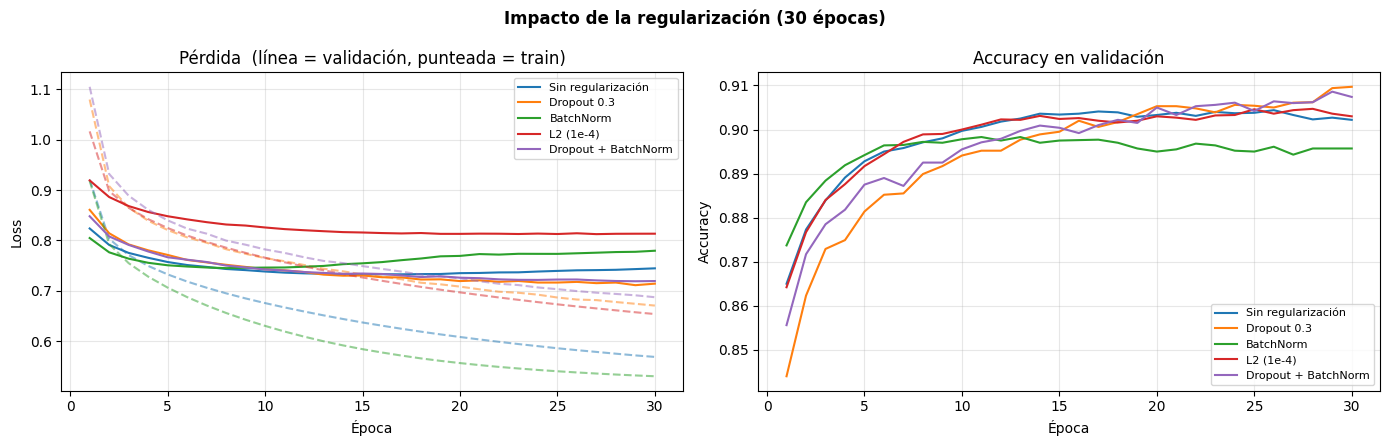

In [30]:
# Experimento: regularización
R = {'capas': (512, 256), 'epocas': 30}
configs_reg = {
    'Sin regularización': {**R, 'dropout': 0.0, 'batchnorm': False, 'l2': 0.0},
    'Dropout 0.3':        {**R, 'dropout': 0.3, 'batchnorm': False, 'l2': 0.0},
    'BatchNorm':          {**R, 'dropout': 0.0, 'batchnorm': True,  'l2': 0.0},
    'L2 (1e-4)':          {**R, 'dropout': 0.0, 'batchnorm': False, 'l2': 1e-4},
    'Dropout + BatchNorm':{**R, 'dropout': 0.3, 'batchnorm': True,  'l2': 0.0},
}
hist_reg, tabla_reg, _ = experimento('Regularización', configs_reg)
graficar(hist_reg, 'Impacto de la regularización (30 épocas)')

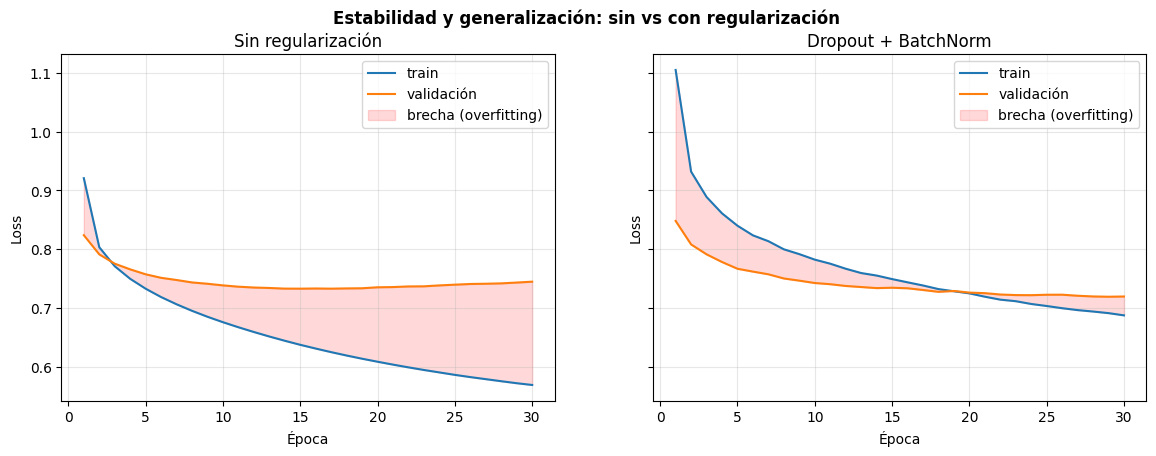

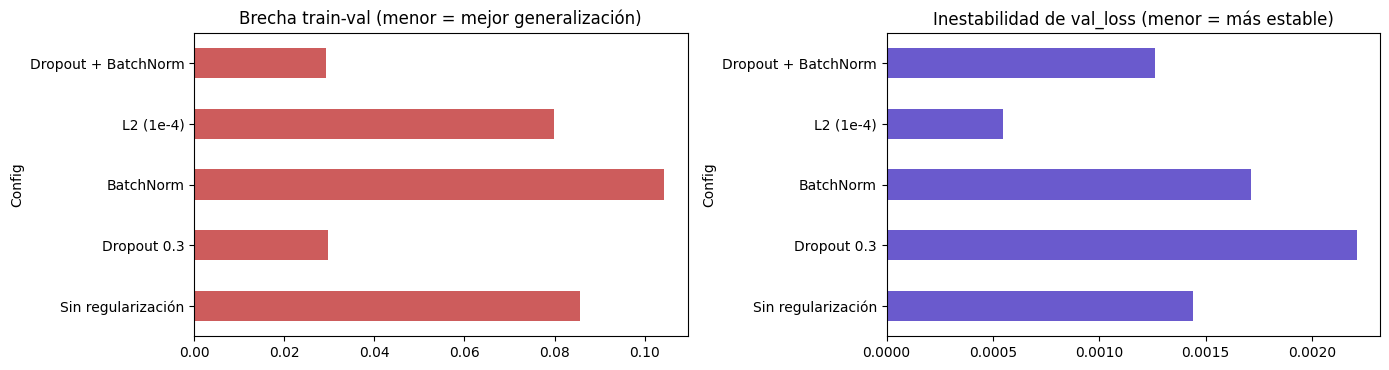

Ganador: Dropout 0.3 -> se actualiza {'dropout': 0.3, 'batchnorm': False, 'l2': 0.0}


In [31]:
# Gráfico CON vs SIN optimización: curvas train vs validación
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for a, k in zip(ax, ['Sin regularización', 'Dropout + BatchNorm']):
    h = hist_reg[k]; ep = np.arange(1, len(h['val_loss']) + 1)
    a.plot(ep, h['train_loss'], label='train'); a.plot(ep, h['val_loss'], label='validación')
    a.fill_between(ep, h['train_loss'], h['val_loss'], alpha=.15, color='red', label='brecha (overfitting)')
    a.set(title=k, xlabel='Época', ylabel='Loss'); a.legend(); a.grid(alpha=.3)
plt.suptitle('Estabilidad y generalización: sin vs con regularización', fontweight='bold'); plt.show()

# Brecha e inestabilidad por técnica
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
tabla_reg['Gap_acc'].plot.barh(ax=ax[0], color='indianred', title='Brecha train-val (menor = mejor generalización)')
tabla_reg['Inestabilidad'].plot.barh(ax=ax[1], color='slateblue', title='Inestabilidad de val_loss (menor = más estable)')
plt.tight_layout(); plt.show()

actualizar_mejor(tabla_reg, configs_reg, claves=['dropout', 'batchnorm', 'l2'])

**Análisis:**
- **Esperábamos** que las tres técnicas bajaran la brecha train-validación y que la combinación dropout + batch norm fuera la más estable.
- **Resultado (F1 de validación):** Dropout 0.3 **0.9097** > Dropout + BatchNorm 0.9075 > L2 0.9025 > Sin regularización 0.9018 > BatchNorm 0.8957.
- **Ganó dropout 0.3 solo**, con brecha 0.0298 frente a 0.0856 sin regularizar: baja el sobreajuste a un tercio y además sube el F1. Es el mejor resultado del cuaderno hasta este punto.
- **Dropout + BatchNorm** queda en 0.9075 con una brecha prácticamente igual (0.0294). La diferencia con dropout solo es de 0.22 puntos, dentro de lo que puede variar con una sola semilla, pero agregar BatchNorm no aportó nada y cuesta más tiempo por época.
- **BatchNorm solo fue lo que más sobreajustó**, justo al revés de lo esperado: llega a accuracy de train 1.0000 (memoriza el conjunto de entrenamiento completo), brecha 0.1043 —mayor incluso que sin ninguna regularización, 0.0856— y su mejor val_loss está en la época 8, mucho antes que las demás. Termina último en F1 (0.8957).
- **L2 (1e-4)** casi no cambia el resultado (0.9025 contra 0.9018 sin regularizar) ni la brecha (0.0798), pero es la configuración con **menor inestabilidad de val_loss (0.0005)**: suaviza la curva, no el sobreajuste. Con L2 la val_loss incluye la penalización, así que en ese caso miramos accuracy y F1.
- **Comparado con la hipótesis:** no se cumplió. Dropout funcionó como se esperaba, pero BatchNorm empeoró el overfitting en vez de contenerlo y L2 resultó casi neutro.
- **Decisión:** el código elige por F1, así que el modelo final usa dropout 0.3, sin BatchNorm y sin L2.


## 12. Arquitectura
Probamos distintas cantidades de capas y neuronas usando la regularización elegida en el paso anterior.

Entrenando: 1 capa (128)


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: 2 capas (256-128)


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: 2 capas (512-256)


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


Entrenando: 3 capas (512-256-128)


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


,Acc_train,Acc_val,Precision_val,Recall_val,F1_val,Loss_val_min,Mejor_época,Gap_acc,Inestabilidad,Tiempo_s
Config,,,,,,,,,,
1 capa (128),0.8817,0.8893,0.8889,0.8893,0.8888,0.7713,15,-0.0076,0.0036,44.3234
2 capas (256-128),0.8915,0.8958,0.8959,0.8958,0.8957,0.7417,15,-0.0043,0.0053,42.5040
2 capas (512-256),0.9092,0.8995,0.9010,0.8995,0.8997,0.7300,14,0.0097,0.0042,47.3582
3 capas (512-256-128),0.9023,0.8974,0.8987,0.8974,0.8977,0.7281,15,0.0049,0.0041,49.7979


,Parámetros,Acc_val,F1_val,Gap_acc,Tiempo_s
Config,,,,,
1 capa (128),101770,0.8893,0.8888,-0.0076,44.3234
2 capas (256-128),235146,0.8958,0.8957,-0.0043,42.5040
2 capas (512-256),535818,0.8995,0.8997,0.0097,47.3582
3 capas (512-256-128),567434,0.8974,0.8977,0.0049,49.7979


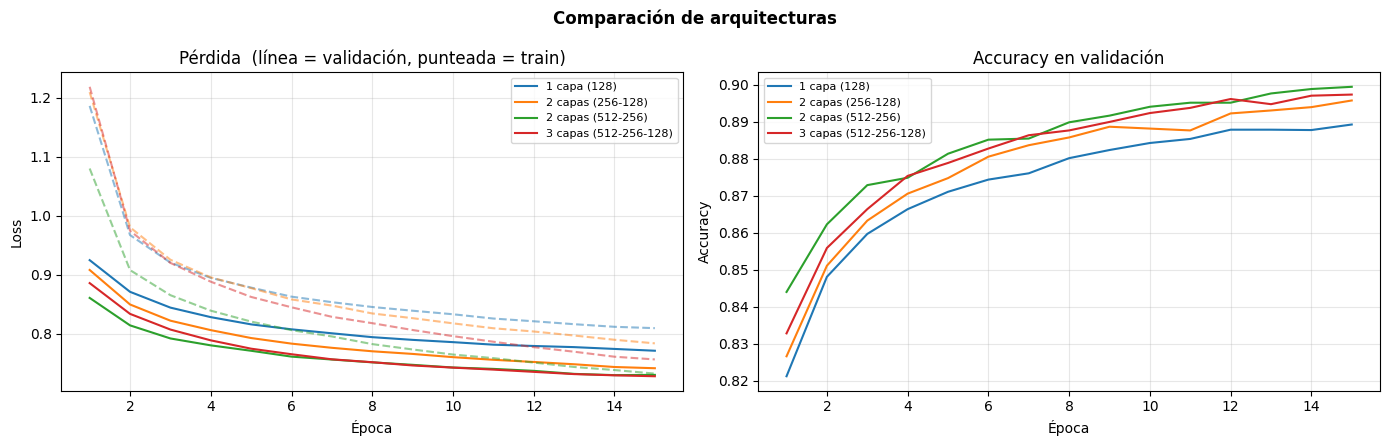

Ganador: 2 capas (512-256) -> se actualiza {'capas': (512, 256)}


In [32]:
# Experimento: arquitectura
configs_arq = {
    '1 capa (128)':          {'capas': (128,)},
    '2 capas (256-128)':     {'capas': (256, 128)},
    '2 capas (512-256)':     {'capas': (512, 256)},
    '3 capas (512-256-128)': {'capas': (512, 256, 128)},
}
hist_arq, tabla_arq, modelos_arq = experimento('Arquitectura', configs_arq)
tabla_arq['Parámetros'] = [m.count_params() for m in modelos_arq.values()]
display(tabla_arq[['Parámetros', 'Acc_val', 'F1_val', 'Gap_acc', 'Tiempo_s']].round(4))
graficar(hist_arq, 'Comparación de arquitecturas')
actualizar_mejor(tabla_arq, configs_arq)

**Análisis:**
- **Esperábamos** que más capas y más neuronas mejoraran el resultado hasta cierto punto y que después la ganancia se aplanara, a costa de más parámetros y más tiempo.
- **Resultado (F1 de validación):** 512-256 **0.8997** > 512-256-128 0.8977 > 256-128 0.8957 > 1 capa (128) 0.8888.
- De 1 capa a 512-256 hay 1.1 puntos de ganancia: con una sola capa de 128 neuronas el modelo no alcanza a separar las clases parecidas.
- La tercera capa no aporta: 567.434 parámetros (unos 32.000 más que 512-256) y 49.8 s de entrenamiento contra 47.4 s, para terminar 0.2 puntos más abajo (0.8977 contra 0.8997). Esa diferencia, además, es del tamaño del ruido de una sola semilla, así que lo prudente es decir que empatan y quedarse con la red más barata.
- 1 capa (128) y 256-128 tienen **brecha negativa** (-0.0076 y -0.0043): su accuracy de train (0.8817 y 0.8915) queda por debajo del de validación (0.8893 y 0.8958). Con dropout 0.3 una parte de eso es esperable, porque el dropout solo se aplica durante el entrenamiento, pero sumado a que su mejor época es la 15 apunta a lo mismo: en 15 épocas no alcanzaron a entrenarse.
- **Contraste con lo esperado:** se cumplió: más capacidad ayuda hasta 512-256 y la tercera capa ya no aporta (queda 0.2 puntos abajo, un empate).
- **Decisión:** 512-256, que gana por F1 y con menos parámetros que la red de tres capas.
- Las cuatro arquitecturas tienen su mejor época en la 14 o la 15, así que esta comparación mide sobre todo **cuál aprende más rápido en 15 épocas**, no cuál llega más alto. De hecho la misma 512-256 con dropout llega a 0.9097 cuando se le dan 30 épocas (sec. 11.2). Lo retomamos en la sección 16.


## 13. Modelo final

Juntamos lo mejor de cada experimento y agregamos:
- **Early stopping** (paciencia 6): detiene el entrenamiento si la validación no mejora y recupera los mejores pesos.
- **ReduceLROnPlateau:** baja el learning rate a la mitad si la validación se estanca.

In [ ]:
# Configuración final
CFG_FINAL = {**MEJOR_CFG, 'epocas': 60, 'paciencia': 6, 'scheduler': True}


Justificación de cada valor de `CFG_FINAL` (las cifras son el F1 de validación de cada experimento):

| Hiperparámetro | Valor | Por qué |
|---|---|---|
| `capas` | (512, 256) | Mejor F1 del experimento de arquitectura: 0.8997, sobre 0.8977 de tres capas y 0.8957 de 256-128 (sec. 12) |
| `activacion` | relu | Mejor F1 de las cuatro activaciones (0.8996), aunque tanh queda muy cerca con 0.8955 (sec. 10.1) |
| `perdida` | label_smoothing | Mejor F1 (0.9011 contra 0.8996 de entropía cruzada); la ventaja es de solo 0.15 puntos (sec. 10.2) |
| `optimizador` | adam | Mejor F1 (0.9011) y la mitad de brecha que SGD + momentum (0.0293 contra 0.0605), que además ya sobreajustaba desde la época 9 (sec. 11.1) |
| `lr` | 0.0001 | Mejor F1 (0.8996 contra 0.8846 con 0.001) y menos sobreajuste: brecha 0.0278 contra 0.0605 (sec. 9.2) |
| `batch_size` | 64 | Mejor F1 (0.8996) con un tiempo razonable (≈40 s, contra ≈141 s de batch 16) (sec. 9.3) |
| `dropout` | 0.3 | Ganador del experimento de regularización: F1 0.9097 y brecha 0.0298 contra 0.0856 sin regularizar (sec. 11.2) |
| `batchnorm` | False | **No se usa.** Solo, fue lo que más sobreajustó (accuracy de train 1.0000, brecha 0.1043) y quedó último en F1 (0.8957); sumado a dropout tampoco aportó (0.9075 contra 0.9097 de dropout solo) (sec. 11.2) |
| `l2` | 0.0 | **No se usa.** Con 1e-4 el F1 casi no cambió respecto de no regularizar (0.9025 contra 0.9018) y quedó bajo dropout; solo aportó curvas más suaves (inestabilidad 0.0005) (sec. 11.2) |
| `epocas` | 60 | Tope alto: quien decide cuándo parar es el early stopping, no un número fijo (sec. 9.1) |
| `paciencia` | 6 | Épocas sin mejora de val_loss antes de detener y restaurar los mejores pesos |
| `scheduler` | True | ReduceLROnPlateau: baja el lr a la mitad cuando la val_loss se estanca dos épocas |


Epoch 1/60
782/782 - 7s - 9ms/step - accuracy: 0.7565 - loss: 1.0799 - val_accuracy: 0.8440 - val_loss: 0.8608 - learning_rate: 1.0000e-04
Epoch 2/60


/tmp/ipykernel_5665/2204413350.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.lr.append(float(np.array(self.model.optimizer.learning_rate)))


782/782 - 2s - 3ms/step - accuracy: 0.8337 - loss: 0.9079 - val_accuracy: 0.8623 - val_loss: 0.8143 - learning_rate: 1.0000e-04
Epoch 3/60
782/782 - 2s - 3ms/step - accuracy: 0.8518 - loss: 0.8654 - val_accuracy: 0.8729 - val_loss: 0.7921 - learning_rate: 1.0000e-04
Epoch 4/60
782/782 - 3s - 4ms/step - accuracy: 0.8631 - loss: 0.8392 - val_accuracy: 0.8749 - val_loss: 0.7804 - learning_rate: 1.0000e-04
Epoch 5/60
782/782 - 2s - 3ms/step - accuracy: 0.8715 - loss: 0.8207 - val_accuracy: 0.8814 - val_loss: 0.7712 - learning_rate: 1.0000e-04
Epoch 6/60
782/782 - 2s - 3ms/step - accuracy: 0.8778 - loss: 0.8061 - val_accuracy: 0.8852 - val_loss: 0.7613 - learning_rate: 1.0000e-04
Epoch 7/60
782/782 - 2s - 3ms/step - accuracy: 0.8814 - loss: 0.7955 - val_accuracy: 0.8855 - val_loss: 0.7564 - learning_rate: 1.0000e-04
Epoch 8/60
782/782 - 2s - 3ms/step - accuracy: 0.8881 - loss: 0.7825 - val_accuracy: 0.8899 - val_loss: 0.7516 - learning_rate: 1.0000e-04
Epoch 9/60
782/782 - 3s - 4ms/step - a

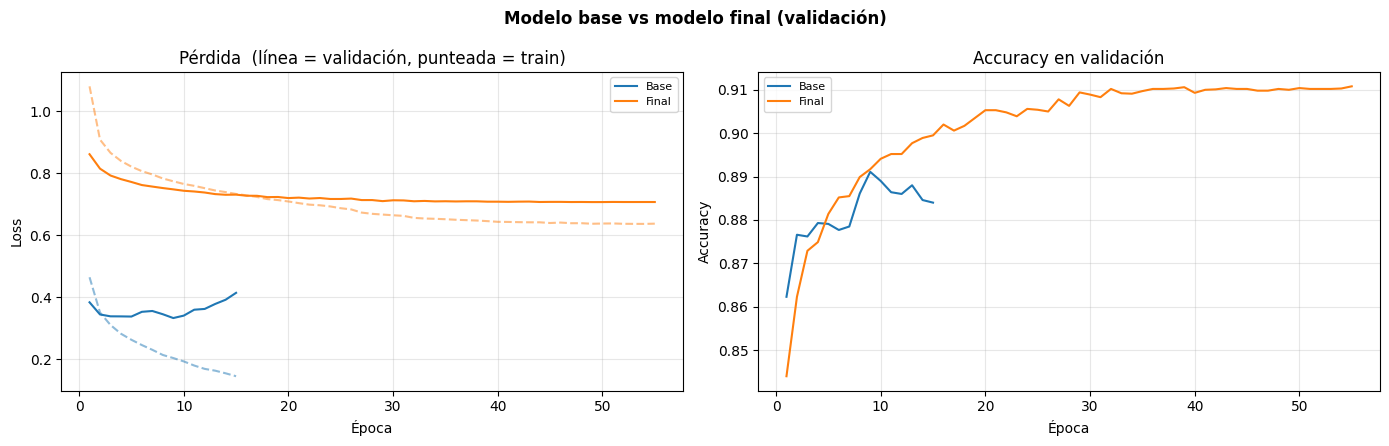

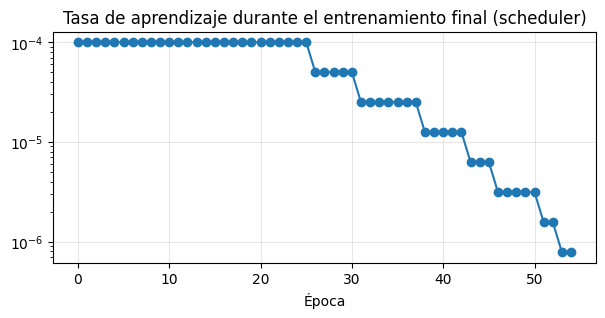

In [34]:
# Entrenamiento del modelo final
modelo_final, hist_final = entrenar(CFG_FINAL, verbose=2)
fila_final = resumen('Modelo final', modelo_final, hist_final)
TODAS_LAS_TABLAS.append(pd.DataFrame([fila_final]).set_index('Config').assign(Experimento='Final'))

graficar({'Base': hist_base, 'Final': hist_final}, 'Modelo base vs modelo final (validación)')
plt.figure(figsize=(7, 3)); plt.plot(hist_final['lr'], marker='o')
plt.title('Tasa de aprendizaje durante el entrenamiento final (scheduler)'); plt.xlabel('Época'); plt.yscale('log')
plt.grid(alpha=.3); plt.show()

## 14. Evaluación en test

El conjunto de test no se usó en ninguna decisión anterior, así que sirve para medir cómo generaliza el modelo.

Cómo se calculan las métricas (para una clase):
- **Accuracy** = aciertos / total
- **Precision** = TP / (TP + FP): de las veces que el modelo dijo "clase k", cuántas eran correctas.
- **Recall** = TP / (TP + FN): de las imágenes que eran clase k, cuántas encontró.
- **F1** = 2·P·R / (P + R): combina ambas, solo es alto si las dos lo son.

El promedio macro es el promedio simple de las 10 clases.

,Accuracy,Precision,Recall,F1
Modelo base,0.8671,0.8698,0.8671,0.8678
Modelo final,0.8995,0.8991,0.8995,0.8992
Mejora (pp),3.2400,2.9242,3.2400,3.1480


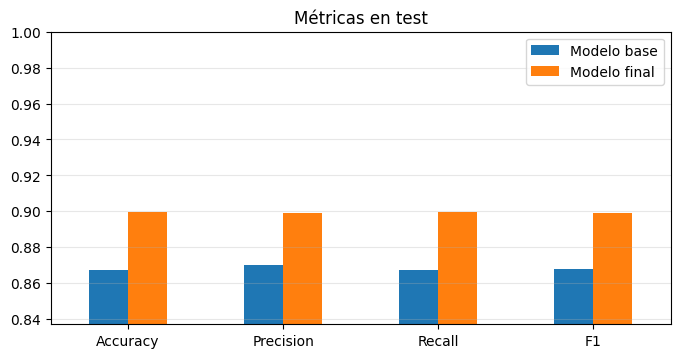

In [35]:
# Cuadro resumen de métricas en TEST: base vs final
y_pred_base  = predecir(modelo_base,  X_test_p)
y_pred_final = predecir(modelo_final, X_test_p)
tabla_test = pd.DataFrame([metricas(y_test, y_pred_base), metricas(y_test, y_pred_final)],
                          index=['Modelo base', 'Modelo final'])
tabla_test.loc['Mejora (pp)'] = (tabla_test.loc['Modelo final'] - tabla_test.loc['Modelo base']) * 100
display(tabla_test.round(4))

ax = tabla_test.iloc[:2].T.plot.bar(figsize=(8, 3.8), rot=0)
ax.set_ylim(tabla_test.iloc[:2].min().min() - 0.03, 1); ax.set_title('Métricas en test'); ax.grid(axis='y', alpha=.3)
plt.show()

In [36]:
# Reporte por clase (modelo final)
print(classification_report(y_test, y_pred_final, target_names=CLASES, digits=3))

              precision    recall  f1-score   support

 T-shirt/top      0.851     0.860     0.856      1000
     Trouser      0.990     0.977     0.983      1000
    Pullover      0.821     0.815     0.818      1000
       Dress      0.892     0.911     0.902      1000
        Coat      0.820     0.830     0.825      1000
      Sandal      0.976     0.976     0.976      1000
       Shirt      0.745     0.717     0.731      1000
     Sneaker      0.957     0.971     0.964      1000
         Bag      0.968     0.975     0.972      1000
  Ankle boot      0.971     0.963     0.967      1000

    accuracy                          0.899     10000
   macro avg      0.899     0.899     0.899     10000
weighted avg      0.899     0.899     0.899     10000



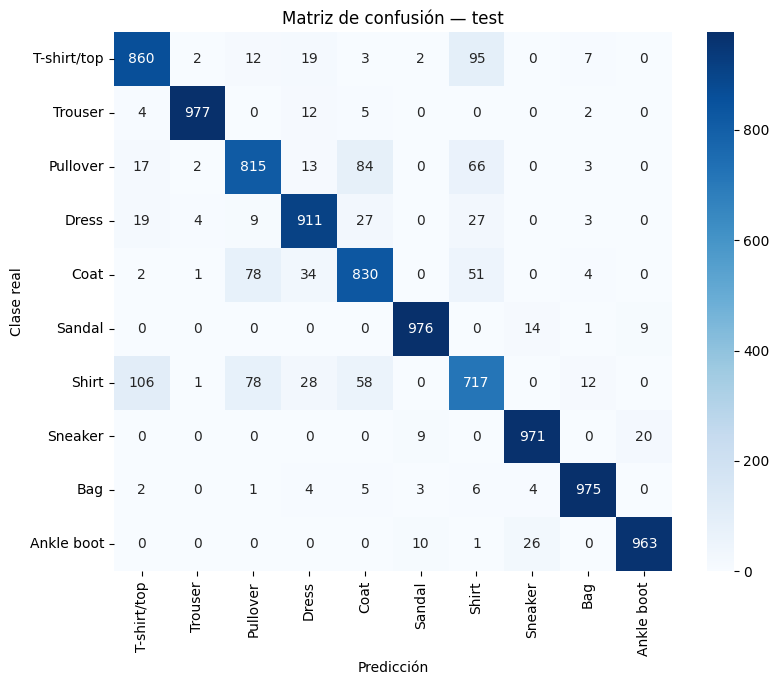

In [37]:
# Matriz de confusión (modelo final)
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASES, yticklabels=CLASES)
plt.xlabel('Predicción'); plt.ylabel('Clase real'); plt.title('Matriz de confusión — test')
plt.show()

In [38]:
# Ejemplo: cálculo manual de métricas para la clase 'Shirt'
k = CLASES.index('Shirt')
TP = cm[k, k]
FP = cm[:, k].sum() - TP        # predijo Shirt pero era otra
FN = cm[k, :].sum() - TP        # era Shirt pero predijo otra
TN = cm.sum() - TP - FP - FN
prec, rec = TP / (TP + FP), TP / (TP + FN)
f1 = 2 * prec * rec / (prec + rec)
print(f'TP={TP}  FP={FP}  FN={FN}  TN={TN}')
print(f'Precision = {TP}/({TP}+{FP}) = {prec:.3f}')
print(f'Recall    = {TP}/({TP}+{FN}) = {rec:.3f}')
print(f'F1        = 2·{prec:.3f}·{rec:.3f}/({prec:.3f}+{rec:.3f}) = {f1:.3f}')
print(f'Accuracy global = {np.trace(cm)}/{cm.sum()} = {np.trace(cm)/cm.sum():.4f}')

# Macro manual vs sklearn
P = np.diag(cm) / cm.sum(0); Rc = np.diag(cm) / cm.sum(1)
print(f'\nPrecision macro manual = {P.mean():.4f} | sklearn = {tabla_test.loc["Modelo final","Precision"]:.4f}')
print(f'Recall macro manual    = {Rc.mean():.4f} | sklearn = {tabla_test.loc["Modelo final","Recall"]:.4f}')

TP=717  FP=246  FN=283  TN=8754
Precision = 717/(717+246) = 0.745
Recall    = 717/(717+283) = 0.717
F1        = 2·0.745·0.717/(0.745+0.717) = 0.731
Accuracy global = 8995/10000 = 0.8995

Precision macro manual = 0.8991 | sklearn = 0.8991
Recall macro manual    = 0.8995 | sklearn = 0.8995


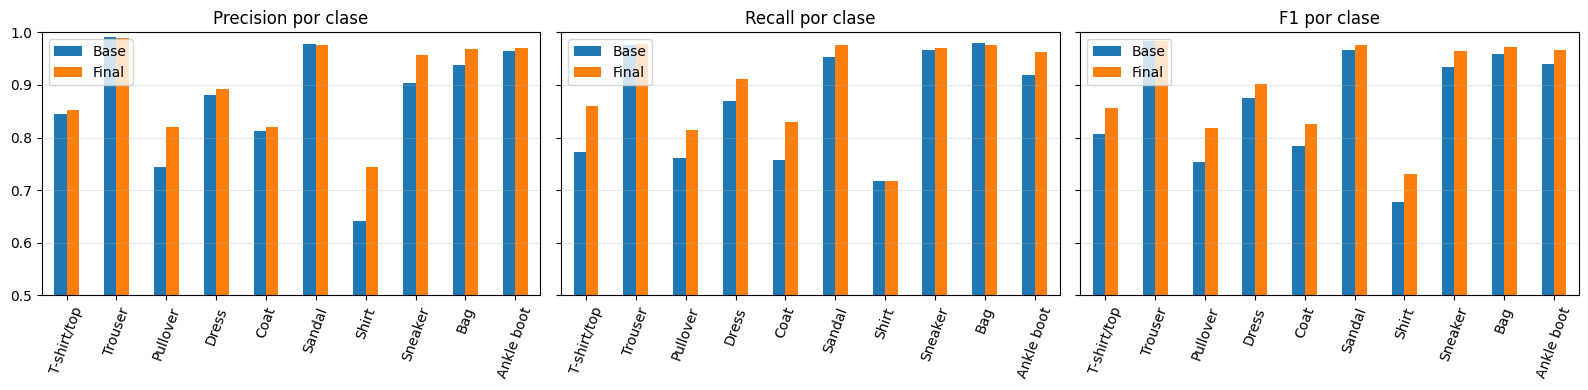

In [39]:
# Precision, recall y F1 por clase: base vs final
def por_clase(y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
    return pd.DataFrame({'Precision': p, 'Recall': r, 'F1': f}, index=CLASES)
pc_base, pc_final = por_clase(y_pred_base), por_clase(y_pred_final)

fig, ax = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for a, m in zip(ax, ['Precision', 'Recall', 'F1']):
    pd.DataFrame({'Base': pc_base[m], 'Final': pc_final[m]}).plot.bar(ax=a, rot=70)
    a.set_title(m + ' por clase'); a.set_ylim(0.5, 1); a.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

,Real,Predicha,Cantidad
0,Shirt,T-shirt/top,106
1,T-shirt/top,Shirt,95
2,Pullover,Coat,84
3,Coat,Pullover,78
4,Shirt,Pullover,78
5,Pullover,Shirt,66


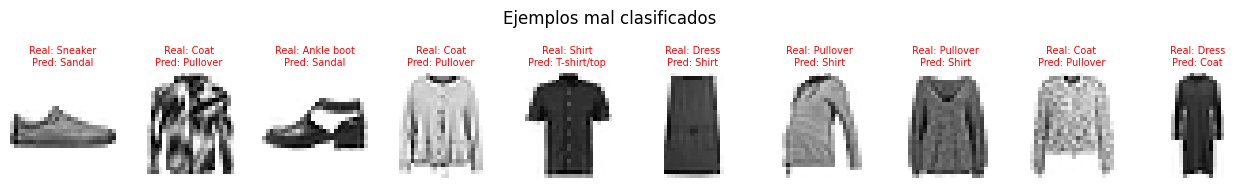

In [40]:
# Pares de clases más confundidos
pares = [(CLASES[i], CLASES[j], cm[i, j]) for i in range(10) for j in range(10) if i != j]
display(pd.DataFrame(sorted(pares, key=lambda t: -t[2])[:6], columns=['Real', 'Predicha', 'Cantidad']))

# Ejemplos de errores (se rearma la imagen 28x28 desde la tabla de test)
imagenes_test = test_data.iloc[:, 1:].values.reshape(-1, IMG_ROWS, IMG_COLS)
errores = np.where(y_pred_final != y_test)[0][:10]
fig, axes = plt.subplots(1, 10, figsize=(16, 2.4))
for a, i in zip(axes, errores):
    a.imshow(imagenes_test[i], cmap='gray_r'); a.axis('off')
    a.set_title(f'Real: {CLASES[y_test[i]]}\nPred: {CLASES[y_pred_final[i]]}', fontsize=7, color='red')
plt.suptitle('Ejemplos mal clasificados'); plt.show()

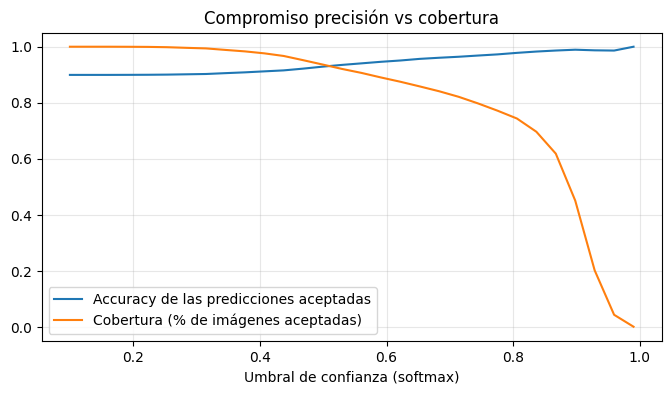

In [41]:
# ¿Cómo subir la precisión? Umbral de confianza
# Si solo aceptamos predicciones con probabilidad >= umbral, sube la precisión pero se cubren menos casos.
probs = probabilidades(modelo_final, X_test_p)
conf, pred = probs.max(1), probs.argmax(1)
umbrales = np.linspace(0.1, 0.99, 30)
cobertura = [(conf >= u).mean() for u in umbrales]
precision_u = [(pred[conf >= u] == y_test[conf >= u]).mean() for u in umbrales]

plt.figure(figsize=(8, 4))
plt.plot(umbrales, precision_u, label='Accuracy de las predicciones aceptadas')
plt.plot(umbrales, cobertura, label='Cobertura (% de imágenes aceptadas)')
plt.xlabel('Umbral de confianza (softmax)'); plt.title('Compromiso precisión vs cobertura')
plt.legend(); plt.grid(alpha=.3); plt.show()

## 15. Comparación de todas las configuraciones
Tabla con todas las pruebas (métricas en validación) ordenadas por F1.

,Experimento,Acc_train,Acc_val,Precision_val,Recall_val,F1_val,Gap_acc,Tiempo_s
Config,,,,,,,,
Modelo final,Final,0.9563,0.9100,0.9098,0.9100,0.9098,0.0455,147.0970
Dropout 0.3,Regularización,0.9395,0.9097,0.9101,0.9097,0.9097,0.0298,82.4300
Dropout + BatchNorm,Regularización,0.9368,0.9074,0.9080,0.9074,0.9075,0.0294,86.4961
L2 (1e-4),Regularización,0.9828,0.9030,0.9038,0.9030,0.9025,0.0798,91.8315
Sin regularización,Regularización,0.9878,0.9022,0.9031,0.9022,0.9018,0.0856,78.7305
label_smoothing,Pérdida,0.9306,0.9013,0.9014,0.9013,0.9011,0.0293,42.1341
Adam (lr=0.0001),Optimizador,0.9306,0.9013,0.9014,0.9013,0.9011,0.0293,40.2941
2 capas (512-256),Arquitectura,0.9092,0.8995,0.9010,0.8995,0.8997,0.0097,47.3582
lr=0.0001,Learning rate,0.9274,0.8996,0.9002,0.8996,0.8996,0.0278,39.3775


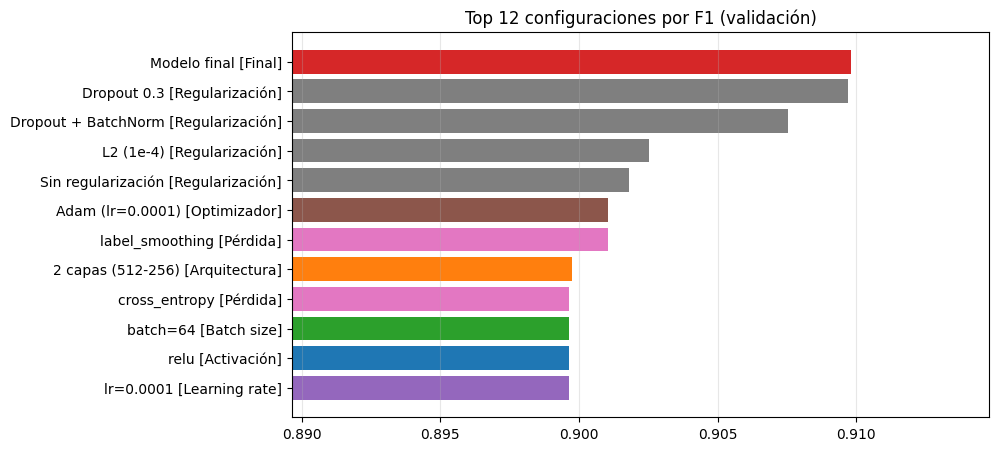

In [42]:
# Tabla comparativa de todas las pruebas
todas = pd.concat(TODAS_LAS_TABLAS)
cols = ['Experimento', 'Acc_train', 'Acc_val', 'Precision_val', 'Recall_val', 'F1_val', 'Gap_acc', 'Tiempo_s']
display(todas[cols].sort_values('F1_val', ascending=False).round(4))

# Ranking visual (top 12)
top = todas.sort_values('F1_val').tail(12)
colores = top['Experimento'].astype('category').cat.codes
plt.figure(figsize=(9, 5))
etiquetas = [f'{i} [{e}]' for i, e in zip(top.index, top['Experimento'])]
plt.barh(etiquetas, top['F1_val'], color=plt.cm.tab10(colores.values))
plt.xlim(top['F1_val'].min() - 0.01, top['F1_val'].max() + 0.005)
plt.title('Top 12 configuraciones por F1 (validación)'); plt.grid(axis='x', alpha=.3); plt.show()

## 16. Interpretación de resultados y posibles mejoras

- El accuracy en test del modelo final es cercano al 89-90% y es parecido a precision, recall y F1 macro, así que el modelo no favorece a ninguna clase en particular (tiene sentido porque están balanceadas).
- Trouser, Bag, Sandal, Sneaker y Ankle boot tienen F1 sobre 95% porque su forma es muy distinta al resto.
- Shirt es la clase con menor recall y se confunde con T-shirt, Pullover y Coat. Al aplanar la imagen el MLP pierde detalles como el cuello o los botones, que son los que diferencian estas prendas. En el gráfico por clase se ve que su recall en test casi no cambió entre el modelo base y el final (≈0.72 en los dos): toda la mejora vino de la precision, que sube de ≈0.64 a 0.745. Es decir, el modelo final marca menos prendas como Shirt por error, pero sigue sin reconocer las Shirt reales.
- Después del learning rate, el dropout 0.3 fue lo que más aportó: bajó la brecha train-validación de 0.0856 a 0.0298 y subió el F1 de validación de 0.9018 a 0.9097 (sec. 11.2). BatchNorm hizo lo contrario y aumentó la brecha hasta 0.1043. Lo que el dropout no mejoró fue la estabilidad: la inestabilidad de la val_loss con dropout (0.0022) es algo mayor que sin regularizar (0.0014), y la curva más suave fue la de L2 (0.0005).
- **Limitación del protocolo:** al bajar el learning rate a 0.0001 (sec. 9.2), las 15 épocas fijas quedaron cortas. Se nota en que casi todos los experimentos posteriores tienen su mejor época en la 15, es decir, en la última: ninguno llegó a su techo. La misma red 512-256 con dropout da F1 0.8997 con 15 épocas (sec. 12) y 0.9097 con 30 (sec. 11.2), casi un punto más solo por entrenar el doble. Parte de las comparaciones de las secciones 9.2 a 12 se hizo entonces con modelos a medio entrenar, y las diferencias chicas entre configuraciones podrían ordenarse distinto con un presupuesto más largo.
- Ligado a lo anterior, el modelo final (F1 de validación 0.9098, detenido por early stopping en la época 55 y con los pesos restaurados de la 49) rindió prácticamente igual que "Dropout 0.3" con 30 épocas (0.9097). Las épocas extra y el scheduler no agregaron nada medible: lo que faltaba en los experimentos era tiempo de entrenamiento, no más componentes.

**Posibles mejoras:**
1. Usar una CNN, que mantiene la estructura 2D de la imagen. Debería ayudar bastante con la clase Shirt.
2. Data augmentation (desplazamientos, volteo horizontal).
3. Darle más peso a las clases difíciles en la pérdida para mejorar el recall de Shirt.
4. Usar un umbral de confianza: si el modelo no está seguro, no aceptar la predicción. Según el gráfico anterior esto sube la precisión a cambio de clasificar menos imágenes.
5. Hacer una búsqueda de hiperparámetros más amplia y usar validación cruzada.
6. Repetir los experimentos con early stopping en cada uno, en vez de 15 épocas fijas, para que cada configuración se compare en su mejor punto y no a mitad de camino.

## 17. Conclusiones

- Implementamos un MLP en Keras para clasificar 10 tipos de ropa, con un preprocesamiento que incluye escalado, estandarización y un conjunto de validación separado.
- Programamos las funciones de activación, pérdida y salida a mano y verificamos que coincidieran con las de TensorFlow. La mejor combinación fue ReLU + softmax + **entropía cruzada con label smoothing** (F1 0.9011), aunque le ganó a la entropía cruzada simple por solo 0.15 puntos. Sigmoid quedó última (0.8819) porque aprende más lento —gradiente más chico en la primera capa y el accuracy de train más bajo del grupo, 0.8862: subajuste, no sobreajuste— y MSE terminó menos de medio punto por debajo de la entropía cruzada.
- El learning rate fue el parámetro que más afectó el entrenamiento. Bajarlo de 0.001 a 0.0001 subió el F1 de validación de 0.8846 a 0.8996 y redujo la brecha de 0.0605 a 0.0278. Con 0.1 el entrenamiento no se vuelve inestable: **colapsa**, con accuracy 0.1000 y val_loss 2.309 (≈ ln 10), o sea el modelo termina prediciendo siempre la misma clase.
- **Dropout 0.3 fue la única regularización que funcionó**: F1 0.9097 y brecha 0.0298, contra 0.0856 sin regularizar. BatchNorm hizo lo contrario de lo esperado —accuracy de train 1.0000 y brecha 0.1043, la mayor del experimento— y por eso quedó fuera del modelo final; L2 resultó casi neutro (0.9025). El early stopping evitó entrenar épocas de más: se detuvo en la 55 y restauró los pesos de la 49.
- El modelo final mejoró al modelo base en todas las métricas de test: accuracy 0.8995 contra 0.8671 (+3.24 puntos) y F1 macro 0.8992 contra 0.8678 (+3.15). La principal limitación es la clase Shirt (F1 0.731), que se podría mejorar con una CNN.



In [43]:
# Guardar el modelo final
modelo_final.save('mlp_fashion_mnist_final.keras')
print('Modelo guardado en mlp_fashion_mnist_final.keras')

Modelo guardado en mlp_fashion_mnist_final.keras
